# Estimating the value of β and γ

$$\beta = \text{effective transmission rate per day}$$
$$\gamma = \text{recovery/removal rate per day}$$


Estimating β and γ from real COVID-19 data requires more than manually choosing values; this is essentially an inverse problem: you observe epidemic data and infer the SIR parameters that best reproduce those observations.

For the standard SIR model for COVID-19,

$$ \frac{dS}{dt}=-\beta\frac{SI}{N} $$ $$ \frac{dI}{dt}=\beta\frac{SI}{N}-\gamma I $$ $$ \frac{dR}{dt}=\gamma I $$

where β is the transmission rate, and γ is the recovery/removal rate Pant et al. (2026) [^1]. For estimating constant β and γ, ideally the dataset should contain: Date, Confirmed, Active infected, Recovered and Total population. This is extremely important because β, γ, and the initial conditions can interact during optimization.

In fact, identifiability studies show that estimating epidemic parameters becomes difficult when important states or parameters are not adequately observed.
Tuncer, N., & Le, T. T. (2018) [^2].

In this section, we will estimate β and γ by implementing the RK4 method with the help of the COVID-19 Dataset for Bangladesh from Kaggle. 


ESTIMATED SIR PARAMETERS
Country        : Bangladesh
Population N   : 164,689,383
Start date     : 2020-03-08
End date       : 2020-07-27
beta           : 0.1715094807
gamma          : 0.0942542420
R0 = beta/gamma: 1.8196473406


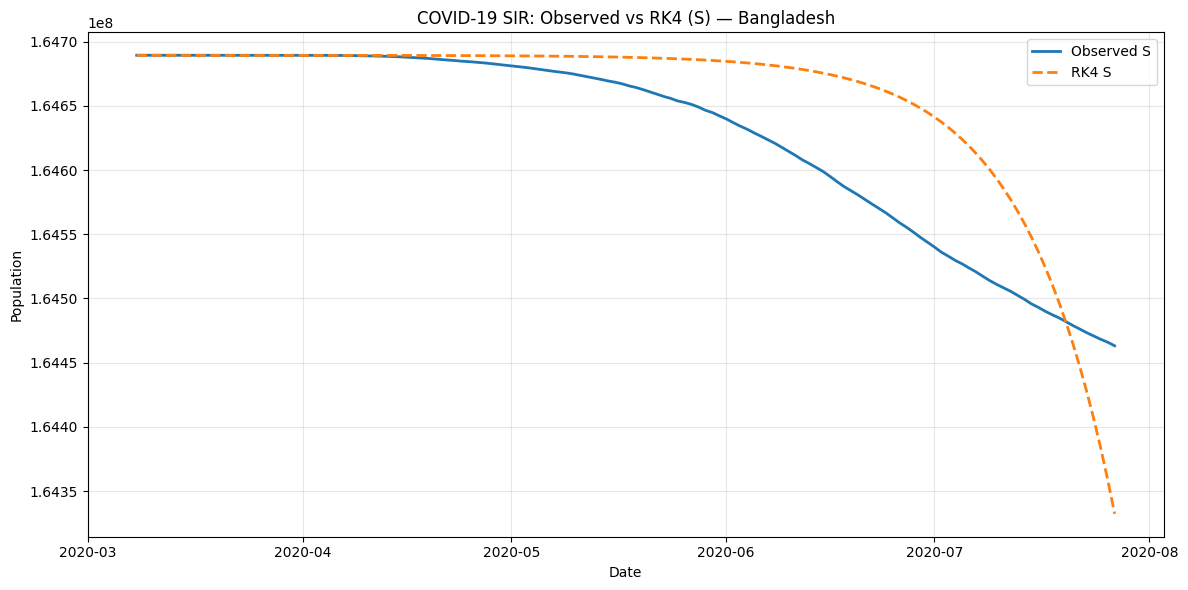

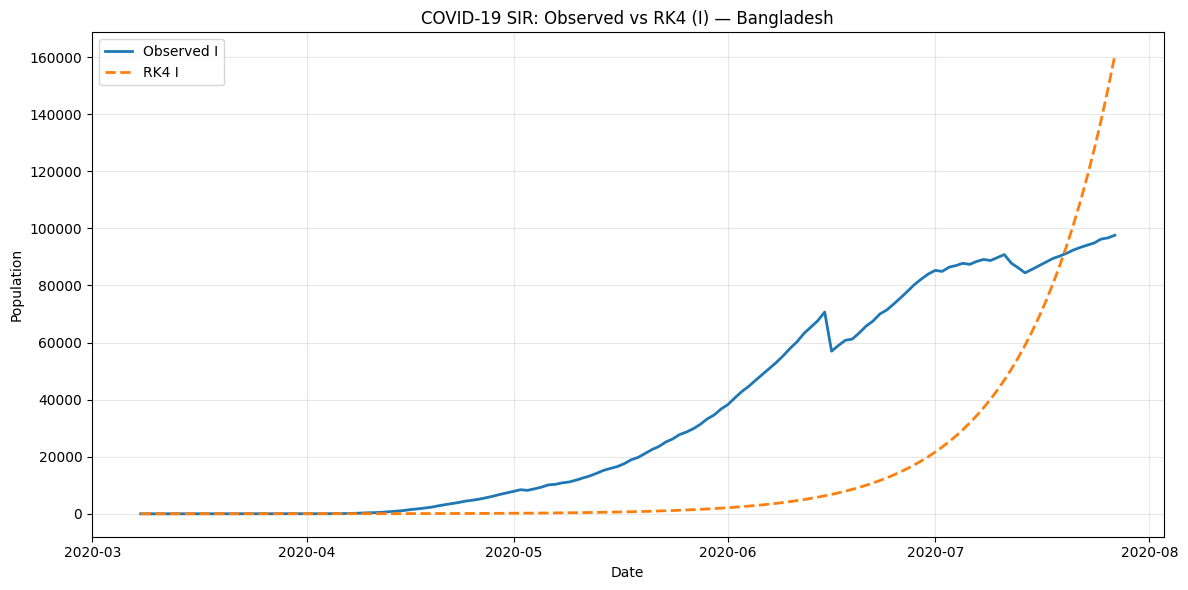

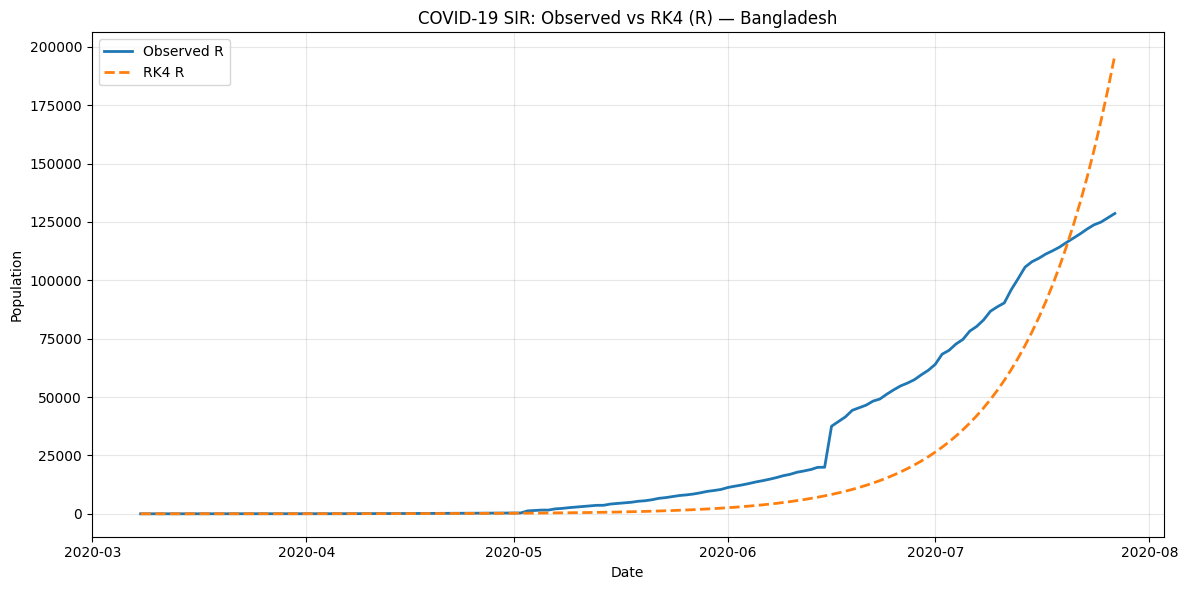


MODEL PERFORMANCE
Compartment           MAE                  MSE          RMSE       R2
          S 34,521.622536 2,550,213,550.984175 50,499.639117 0.522849
          I 22,818.473300 1,050,476,888.634334 32,411.061208 0.168832
          R 11,727.681623   375,884,687.230241 19,387.745801 0.756780

First 10 RK4 results:
      Date        S_RK4    I_RK4    R_RK4
2020-03-08 1.646894e+08 3.000000 0.000000
2020-03-09 1.646894e+08 3.240953 0.293972
2020-03-10 1.646894e+08 3.501259 0.611555
2020-03-11 1.646894e+08 3.782473 0.954646
2020-03-12 1.646894e+08 4.086272 1.325292
2020-03-13 1.646894e+08 4.414473 1.725709
2020-03-14 1.646894e+08 4.769033 2.158286
2020-03-15 1.646894e+08 5.152071 2.625606
2020-03-16 1.646894e+08 5.565874 3.130461
2020-03-17 1.646894e+08 6.012912 3.675864

FILES CREATED
CSV     : /kaggle/working/bangladesh_sir_rk4_results.csv
Excel   : /kaggle/working/bangladesh_sir_rk4_results.xlsx
Metrics : /kaggle/working/bangladesh_sir_metrics.csv
S plot  : /kaggle/working/banglad

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# COVID-19 SIR MODEL
# Parameter estimation + classical RK4 solution + metrics
# ============================================================

# ------------------------- CONFIG ----------------------------
INPUT_FILE = "/kaggle/input/datasets/abushayid/covid19/covid_19_clean_complete.csv"
COUNTRY = "Bangladesh"

# IMPORTANT:
# Use the actual total population of the selected country.
# This value is the 2020 population used for the Bangladesh example.
N = 164_689_383

OUTPUT_DIR = Path("/kaggle/working/")

CSV_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_rk4_results.csv"
EXCEL_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_rk4_results.xlsx"
METRICS_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_metrics.csv"

PLOT_S = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_S_observed_vs_rk4.png"
PLOT_I = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_I_observed_vs_rk4.png"
PLOT_R = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_R_observed_vs_rk4.png"


# ============================================================
# 1. READ COVID-19 DATA
# ============================================================
df = pd.read_csv(INPUT_FILE)

required_columns = [
    "Country/Region", "Date", "Confirmed",
    "Deaths", "Recovered", "Active"
]

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Date"] = pd.to_datetime(df["Date"])

data = df[df["Country/Region"].eq(COUNTRY)].copy()

if data.empty:
    raise ValueError(
        f"No data found for '{COUNTRY}'. "
        f"Check the COUNTRY variable."
    )

# If the country has province/state rows, aggregate them by date.
data = (
    data.groupby("Date", as_index=False)
    [["Confirmed", "Deaths", "Recovered", "Active"]]
    .sum()
    .sort_values("Date")
    .reset_index(drop=True)
)

# ============================================================
# Construct observed S, I, R
# ============================================================
# Active = I
# Recovered + Deaths = R (removed)
# S = N - I - R
#
# Note: deaths are included in R because classical SIR has
# a single removed compartment.
data["I_obs"] = data["Active"].astype(float)
data["R_obs"] = (
    data["Recovered"].astype(float)
    + data["Deaths"].astype(float)
)
data["S_obs"] = N - data["I_obs"] - data["R_obs"]

if (data["S_obs"] < 0).any():
    raise ValueError(
        "Some S_obs values are negative. "
        "Increase/correct N for the selected country."
    )

# The dataset begins with zero active infections.
# Start estimation at the first day with I > 0.
positive_indices = np.flatnonzero(
    data["I_obs"].to_numpy() > 0
)

if len(positive_indices) == 0:
    raise ValueError("No positive Active-infection observations found.")

start_idx = int(positive_indices[0])

fit_data = data.iloc[start_idx:].copy().reset_index(drop=True)

S_obs = fit_data["S_obs"].to_numpy(dtype=float)
I_obs = fit_data["I_obs"].to_numpy(dtype=float)
R_obs = fit_data["R_obs"].to_numpy(dtype=float)

t = np.arange(len(fit_data), dtype=float)

# Initial SIR state
y0 = np.array(
    [S_obs[0], I_obs[0], R_obs[0]],
    dtype=float
)

# ============================================================
# 2. ESTIMATE beta AND gamma
# ============================================================

def sir_rhs(y, beta, gamma, population):
    """
    Normalized SIR equations:
        dS/dt = -beta*S*I/N
        dI/dt =  beta*S*I/N - gamma*I
        dR/dt =  gamma*I
    """
    S, I, R = y

    dS = -beta * S * I / population
    dI = beta * S * I / population - gamma * I
    dR = gamma * I

    return np.array([dS, dI, dR], dtype=float)


def simulate_for_estimation(beta, gamma):
    """
    Numerically integrate SIR during parameter fitting.
    solve_ivp is used only for parameter estimation.
    The final reported solution is produced independently
    with classical RK4 below.
    """
    solution = solve_ivp(
        lambda time, state: sir_rhs(
            state, beta, gamma, N
        ),
        [t[0], t[-1]],
        y0,
        t_eval=t,
        method="RK45",
        rtol=1e-7,
        atol=1e-2
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    return solution.y


observed = np.vstack([S_obs, I_obs, R_obs])

# Normalize residuals so the very large S compartment does not
# completely dominate I and R during optimization.
scales = np.array([
    max(N, 1.0),
    max(I_obs.max(), 1.0),
    max(R_obs.max(), 1.0)
])


def residual_log_parameters(log_parameters):
    """
    Optimize log(beta), log(gamma), which guarantees
    beta > 0 and gamma > 0.
    """
    beta, gamma = np.exp(log_parameters)

    predicted = simulate_for_estimation(beta, gamma)

    return (
        (predicted - observed)
        / scales[:, None]
    ).ravel()


# Initial guess; change if desired.
initial_guess = np.array([0.30, 0.10])

fit = least_squares(
    residual_log_parameters,
    np.log(initial_guess),
    bounds=(
        np.log([1e-6, 1e-6]),
        np.log([10.0, 10.0])
    ),
    max_nfev=2000
)

beta, gamma = np.exp(fit.x)

# Basic reproduction number for the normalized SIR model.
R0 = beta / gamma

print("\n" + "=" * 70)
print("ESTIMATED SIR PARAMETERS")
print("=" * 70)
print(f"Country        : {COUNTRY}")
print(f"Population N   : {N:,}")
print(f"Start date     : {fit_data['Date'].iloc[0].date()}")
print(f"End date       : {fit_data['Date'].iloc[-1].date()}")
print(f"beta           : {beta:.10f}")
print(f"gamma          : {gamma:.10f}")
print(f"R0 = beta/gamma: {R0:.10f}")
print("=" * 70)


# ============================================================
# 3. CLASSICAL RK4 SOLUTION
# ============================================================

def rk4_sir(y_initial, beta, gamma, population,
            n_steps, h=1.0):
    """
    Classical fourth-order Runge-Kutta solution
    for the normalized SIR model.
    """

    y = np.array(y_initial, dtype=float)

    result = np.zeros(
        (n_steps + 1, 3),
        dtype=float
    )

    result[0] = y

    def f(state):
        return sir_rhs(
            state,
            beta,
            gamma,
            population
        )

    for step in range(n_steps):

        k1 = f(y)
        k2 = f(y + 0.5 * h * k1)
        k3 = f(y + 0.5 * h * k2)
        k4 = f(y + h * k3)

        y = y + (
            h / 6.0
        ) * (
            k1 + 2*k2 + 2*k3 + k4
        )

        # Numerical safeguard.
        y = np.maximum(y, 0.0)

        result[step + 1] = y

    return result


rk4_solution = rk4_sir(
    y_initial=y0,
    beta=beta,
    gamma=gamma,
    population=N,
    n_steps=len(fit_data) - 1,
    h=1.0
)

fit_data["S_RK4"] = rk4_solution[:, 0]
fit_data["I_RK4"] = rk4_solution[:, 1]
fit_data["R_RK4"] = rk4_solution[:, 2]


# ============================================================
# 4. COMPLETE S, I, R VALUES FOR EVERY DAY
# ============================================================

results = fit_data[
    [
        "Date",
        "Confirmed",
        "Deaths",
        "Recovered",
        "Active",
        "S_obs",
        "I_obs",
        "R_obs",
        "S_RK4",
        "I_RK4",
        "R_RK4"
    ]
].copy()


# ============================================================
# 5. SAVE CSV AND EXCEL
# ============================================================

results.to_csv(
    CSV_FILE,
    index=False
)

metrics_rows = []

for compartment, observed_column, rk4_column in [
    ("S", "S_obs", "S_RK4"),
    ("I", "I_obs", "I_RK4"),
    ("R", "R_obs", "R_RK4")
]:

    y_true = results[observed_column].to_numpy()
    y_pred = results[rk4_column].to_numpy()

    mae = mean_absolute_error(
        y_true, y_pred
    )

    mse = mean_squared_error(
        y_true, y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true, y_pred
    )

    metrics_rows.append({
        "Compartment": compartment,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

metrics = pd.DataFrame(metrics_rows)

parameter_table = pd.DataFrame({
    "Parameter": [
        "Country",
        "Population_N",
        "beta",
        "gamma",
        "R0",
        "Start_Date",
        "End_Date"
    ],
    "Value": [
        COUNTRY,
        N,
        beta,
        gamma,
        R0,
        str(results["Date"].iloc[0].date()),
        str(results["Date"].iloc[-1].date())
    ]
})

with pd.ExcelWriter(
    EXCEL_FILE,
    engine="openpyxl"
) as writer:

    results.to_excel(
        writer,
        sheet_name="SIR_RK4_Results",
        index=False
    )

    metrics.to_excel(
        writer,
        sheet_name="Metrics",
        index=False
    )

    parameter_table.to_excel(
        writer,
        sheet_name="Parameters",
        index=False
    )

metrics.to_csv(
    METRICS_FILE,
    index=False
)


# ============================================================
# 6. OBSERVED VS RK4 PLOTS
# ============================================================
# Three separate figures are used because S is much larger
# than I and R and would otherwise hide their differences.

def make_comparison_plot(
    date,
    observed_values,
    rk4_values,
    compartment,
    filename
):

    plt.figure(figsize=(12, 6))

    plt.plot(
        date,
        observed_values,
        label=f"Observed {compartment}",
        linewidth=2
    )

    plt.plot(
        date,
        rk4_values,
        "--",
        label=f"RK4 {compartment}",
        linewidth=2
    )

    plt.xlabel("Date")
    plt.ylabel("Population")
    plt.title(
        f"COVID-19 SIR: Observed vs RK4 "
        f"({compartment}) — {COUNTRY}"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


make_comparison_plot(
    results["Date"],
    results["S_obs"],
    results["S_RK4"],
    "S",
    PLOT_S
)

make_comparison_plot(
    results["Date"],
    results["I_obs"],
    results["I_RK4"],
    "I",
    PLOT_I
)

make_comparison_plot(
    results["Date"],
    results["R_obs"],
    results["R_RK4"],
    "R",
    PLOT_R
)


# ============================================================
# 7. PRINT METRICS
# ============================================================

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(
    metrics.to_string(
        index=False,
        float_format=lambda x: f"{x:,.6f}"
    )
)

print("\nFirst 10 RK4 results:")
print(
    results[
        [
            "Date",
            "S_RK4",
            "I_RK4",
            "R_RK4"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("FILES CREATED")
print("=" * 70)
print(f"CSV     : {CSV_FILE}")
print(f"Excel   : {EXCEL_FILE}")
print(f"Metrics : {METRICS_FILE}")
print(f"S plot  : {PLOT_S}")
print(f"I plot  : {PLOT_I}")
print(f"R plot  : {PLOT_R}")
print("=" * 70)

2026-09-03 06:21:54.969705: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "COVID19_SEIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,492 (64.42 KB)

 Trainable params: 16,492 (64.42 KB)

...

None
Epoch 1/150
245/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0356 - mae: 0.0969

2026-09-03 06:21:56.978957: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0180 - mae: 0.0606 - val_loss: 0.0121 - val_mae: 0.0441
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084 - mae: 0.0377 - val_loss: 0.0066 - val_mae: 0.0294
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - mae: 0.0227 - val_loss: 0.0039 - val_mae: 0.0188
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - mae: 0.0159 - val_loss: 0.0019 - val_mae: 0.0146
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - mae: 0.0111 - val_loss: 0.0014 - val_mae: 0.0136
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.5927e-04 - mae: 0.0090 - val_loss: 2.4520e-04 - val_mae: 0.0063
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1409e-04 - mae: 0.0058 - val_loss: 3.8072e-04 - val_mae: 0.0078
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.0923e-04 - mae: 0.0066 - val_loss: 0.0022 - val_mae: 0.0162
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━

2026-09-03 06:23:40.728298: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


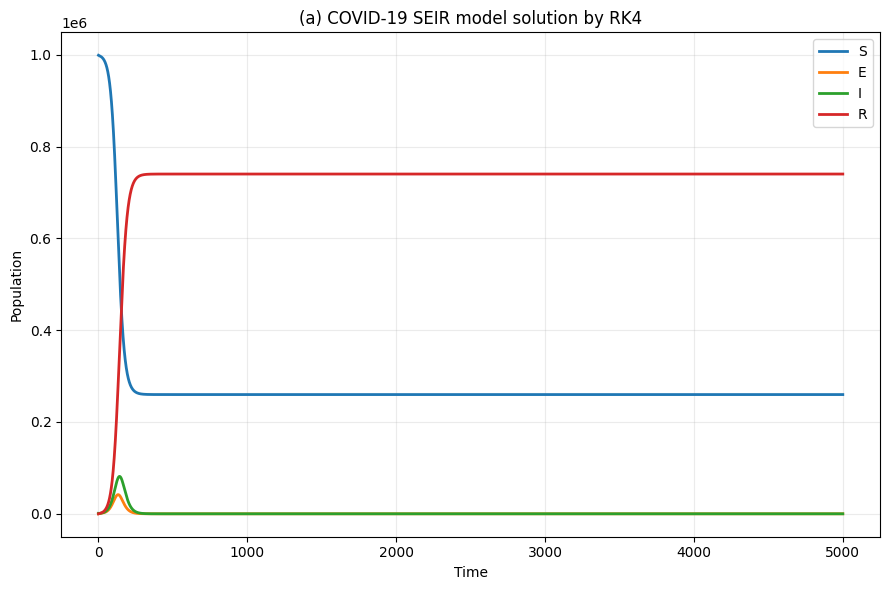

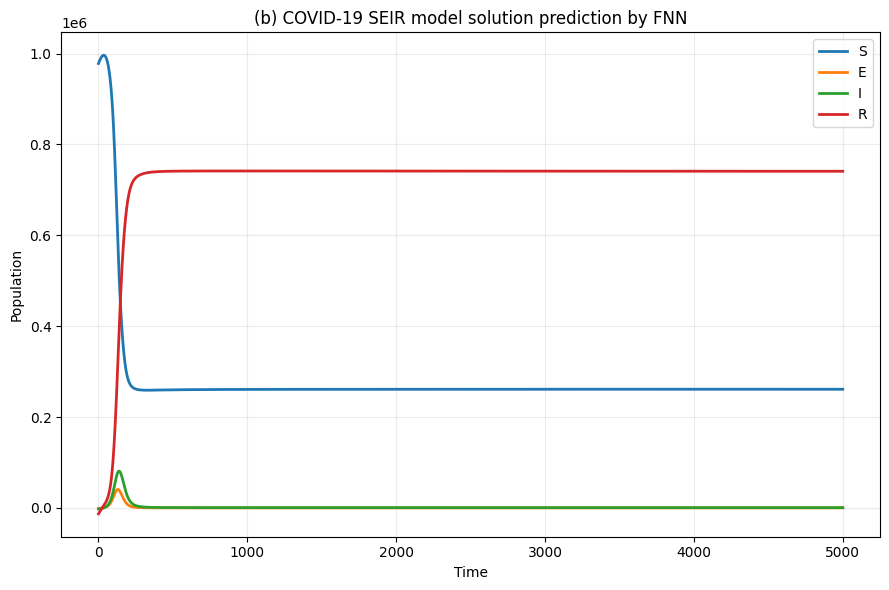

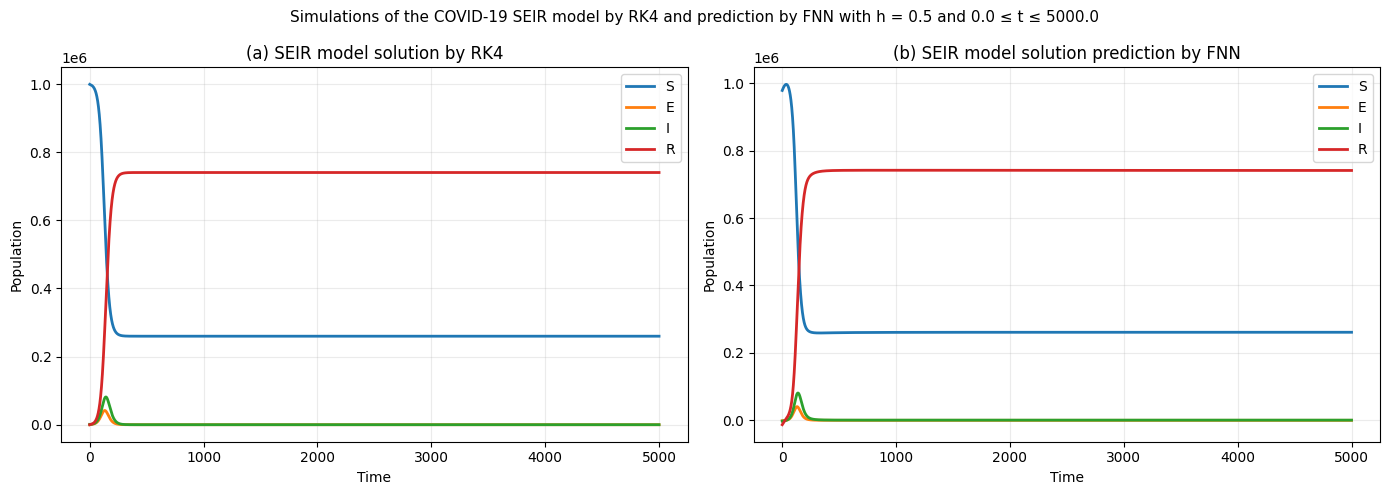

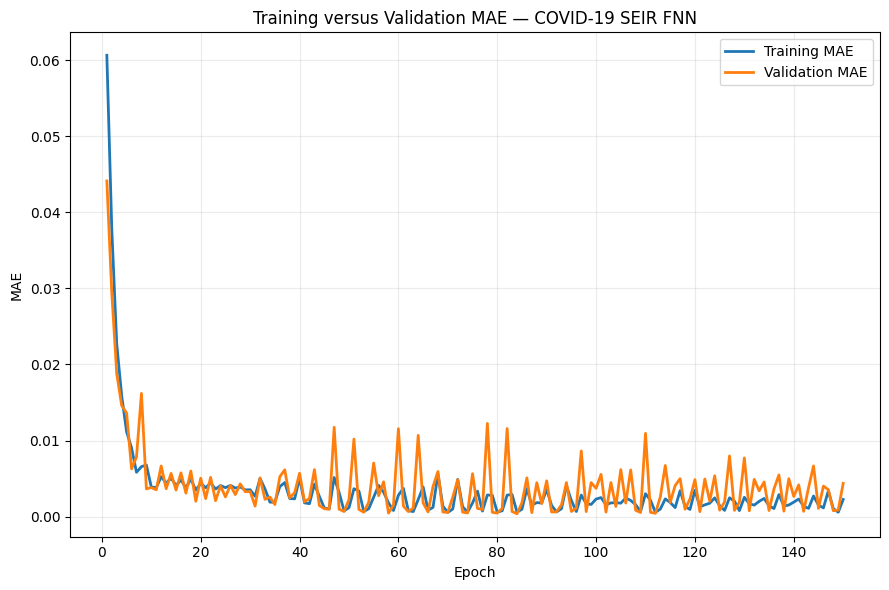

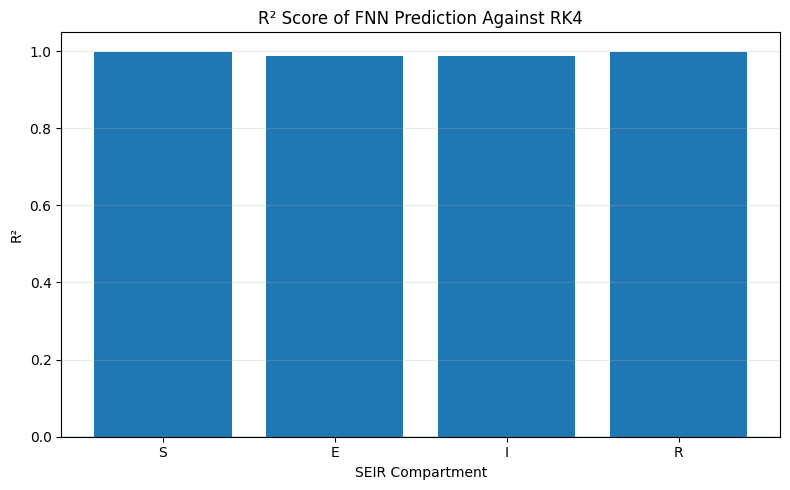

/tmp/ipykernel_95/3678915318.py:1075: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(
/tmp/ipykernel_95/3678915318.py:1081: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  res.to_excel(
/tmp/ipykernel_95/3678915318.py:1087: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  metrics.to_excel(
/tmp/ipykernel_95/3678915318.py:1093: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  normdf.to_excel(
/tmp/ipykernel_95/3678915318.py:1099: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  Hdf.to_excel(
/tmp/ipykernel_95/3678915318.py:1105: FutureWarn


COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED
beta = 0.17150948
gamma = 0.09425424
sigma = 0.19230769
latent period = 5.20 days
beta/gamma = 1.819647

Initial state: S0=999,000, E0=0, I0=1,000, R0=0
N = 1,000,000

RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment         MAE          MSE        RMSE       R2
          S 1940.653667 1.681622e+07 4100.758428 0.998510
          E  134.361332 2.843884e+05  533.280822 0.986281
          I  692.519063 1.022104e+06 1010.991575 0.987683
          R 1964.095479 3.729509e+07 6106.970383 0.997090

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.002625        0.000031              99.737476
          E        0.003099        0.000156              99.690129
          I        0.008374        0.000147              99.162568
          R        0.002609        0.000067              99.739074

Population conservation check:
RK4 maximum absolute error = 0

In [2]:
import os, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# COVID-19 SEIR RK4-FNN Synthetic Experiment
#
# Method:
#   1. Generate synthetic SEIR data using RK4
#   2. Min-Max normalization
#   3. 80/20 train-validation split
#   4. FNN input = t
#   5. FNN output = [S(t), E(t), I(t), R(t)]
#   6. MSE loss
#   7. Adam optimizer
#   8. tanh activation
#   9. 150 epochs
#
# SEIR compartments:
#   S = Susceptible
#   E = Exposed
#   I = Infectious
#   R = Recovered
# ============================================================


# ============================================================
# Output directory
# ============================================================

OUT = Path('/kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)


# ============================================================
# SEIR PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

# Sigma = rate at which exposed individuals become infectious
# Mean latent/incubation period = 1 / SIGMA
SIGMA = 1.0 / 5.2

# Initial conditions
S0 = 999000.0
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population
N = S0 + E0 + I0 + R0


# ============================================================
# TIME SETTINGS
# ============================================================

T0 = 0.0
T1 = 5000.0
H = 0.5


# ============================================================
# FNN SETTINGS
# ============================================================

SEED = 42

EPOCHS = 150
BATCH_SIZE = 32

# Same published-style architecture as your SIR code
HIDDEN = [16, 128, 80, 40, 16]


# ============================================================
# RANDOM SEED
# ============================================================

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ============================================================
# SEIR DIFFERENTIAL EQUATIONS
# ============================================================
#
# dS/dt = -beta*S*I/N
#
# dE/dt = beta*S*I/N - sigma*E
#
# dI/dt = sigma*E - gamma*I
#
# dR/dt = gamma*I
#
# ============================================================

def rhs(t, y):

    S, E, I, R = y

    dS = -BETA * S * I / N

    dE = BETA * S * I / N - SIGMA * E

    dI = SIGMA * E - GAMMA * I

    dR = GAMMA * I

    return np.array([dS, dE, dI, dR])


# ============================================================
# RK4 ONE STEP
# ============================================================

def rk4_step(t, y, h):

    k1 = h * rhs(t, y)

    k2 = h * rhs(
        t + h / 2,
        y + k1 / 2
    )

    k3 = h * rhs(
        t + h / 2,
        y + k2 / 2
    )

    k4 = h * rhs(
        t + h,
        y + k3
    )

    y_next = y + (
        k1 + 2*k2 + 2*k3 + k4
    ) / 6

    # Avoid negative populations
    y_next = np.maximum(y_next, 0.0)

    return y_next


# ============================================================
# GENERATE TIME ARRAY
# ============================================================

t = np.arange(
    T0,
    T1 + H / 2,
    H
)

t[-1] = T1


# ============================================================
# RK4 SYNTHETIC DATA GENERATION
# ============================================================

y = np.zeros(
    (len(t), 4)
)

# Initial conditions
y[0] = [
    S0,
    E0,
    I0,
    R0
]


# Run RK4
for j in range(len(t) - 1):

    y[j + 1] = rk4_step(
        t[j],
        y[j],
        H
    )


# ============================================================
# CREATE RK4 DATAFRAME
# ============================================================

rk4 = pd.DataFrame({
    't': t,
    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3]
})


# Total population
rk4['Total_RK4'] = rk4[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


# Population conservation error
rk4['Population_Error'] = (
    rk4['Total_RK4'] - N
)


# Save RK4 synthetic dataset
rk4.to_csv(
    OUT / 'COVID19_SEIR_RK4_synthetic_data.csv',
    index=False
)


# ============================================================
# ARTICLE-STYLE FNN
# ============================================================
#
# Input:
#       t
#
# Output:
#       S(t), E(t), I(t), R(t)
#
# ============================================================

X = t.reshape(-1, 1)

Y = y.copy()


# ============================================================
# MIN-MAX NORMALIZATION
# ============================================================

xsc = MinMaxScaler()

ysc = MinMaxScaler()


Xs = xsc.fit_transform(X)

Ys = ysc.fit_transform(Y)


# ============================================================
# 80/20 TRAIN-VALIDATION SPLIT
# ============================================================

Xtr, Xva, Ytr, Yva = train_test_split(
    Xs,
    Ys,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)


# ============================================================
# BUILD FNN
# ============================================================

model = keras.Sequential(
    [
        layers.Input((1,))
    ]
    +
    [
        layers.Dense(
            u,
            activation='tanh'
        )
        for u in HIDDEN
    ]
    +
    [
        layers.Dense(
            4,
            activation='linear'
        )
    ],
    name='COVID19_SEIR_FNN'
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(
            name='mae'
        )
    ]
)


print(model.summary())


# ============================================================
# TRAIN FNN
# ============================================================

hist = model.fit(
    Xtr,
    Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


# ============================================================
# TRAINING HISTORY
# ============================================================

Hdf = pd.DataFrame(
    hist.history
)

Hdf.insert(
    0,
    'epoch',
    np.arange(
        1,
        len(Hdf) + 1
    )
)


Hdf.to_csv(
    OUT / 'FNN_training_history.csv',
    index=False
)


# ============================================================
# FULL-DOMAIN FNN PREDICTION
# ============================================================

pred_scaled = model.predict(
    Xs,
    batch_size=BATCH_SIZE,
    verbose=1
)


# Convert back to original population scale
pred = ysc.inverse_transform(
    pred_scaled
)


# ============================================================
# EXTRACT COMPARTMENTS
# ============================================================

Sfnn = pred[:, 0]
Efnn = pred[:, 1]
Ifnn = pred[:, 2]
Rfnn = pred[:, 3]


# Optional non-negative predictions
Sfnn = np.maximum(
    Sfnn,
    0
)

Efnn = np.maximum(
    Efnn,
    0
)

Ifnn = np.maximum(
    Ifnn,
    0
)

Rfnn = np.maximum(
    Rfnn,
    0
)


# ============================================================
# RESULTS DATAFRAME
# ============================================================

res = pd.DataFrame({

    't': t,

    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3],

    'S_FNN': Sfnn,
    'E_FNN': Efnn,
    'I_FNN': Ifnn,
    'R_FNN': Rfnn
})


# ============================================================
# TOTAL POPULATION
# ============================================================

res['RK4_Total'] = res[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


res['FNN_Total'] = res[
    [
        'S_FNN',
        'E_FNN',
        'I_FNN',
        'R_FNN'
    ]
].sum(axis=1)


# ============================================================
# FNN TOTAL POPULATION ERROR
# ============================================================

res['FNN_Total_Error'] = (
    res['FNN_Total'] - N
)


# ============================================================
# COMPARTMENT-WISE ERRORS
# ============================================================

res['S_Error'] = (
    res['S_FNN'] - res['S_RK4']
)

res['E_Error'] = (
    res['E_FNN'] - res['E_RK4']
)

res['I_Error'] = (
    res['I_FNN'] - res['I_RK4']
)

res['R_Error'] = (
    res['R_FNN'] - res['R_RK4']
)


# Save complete results
res.to_csv(
    OUT / 'COVID19_SEIR_RK4_vs_FNN_complete.csv',
    index=False
)


# ============================================================
# METRICS
# ============================================================

rows = []


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    actual = y[:, k]

    prediction = pred[:, k]


    mse = mean_squared_error(
        actual,
        prediction
    )


    rows.append({

        'Compartment': name,

        'MAE': mean_absolute_error(
            actual,
            prediction
        ),

        'MSE': mse,

        'RMSE': np.sqrt(mse),

        'R2': r2_score(
            actual,
            prediction
        )

    })


metrics = pd.DataFrame(
    rows
)


metrics.to_csv(
    OUT / 'COVID19_SEIR_RK4_FNN_metrics.csv',
    index=False
)


# ============================================================
# NORMALIZED MAE / ACCURACY-LIKE SCORE
# ============================================================

norm = []


# Use non-negative predictions for this section
P_for_scaling = np.column_stack(
    [
        Sfnn,
        Efnn,
        Ifnn,
        Rfnn
    ]
)


Pscaled = ysc.transform(
    P_for_scaling
)


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    mae = mean_absolute_error(
        Ys[:, k],
        Pscaled[:, k]
    )

    mse = mean_squared_error(
        Ys[:, k],
        Pscaled[:, k]
    )


    norm.append({

        'Compartment': name,

        'Normalized_MAE': mae,

        'Normalized_MSE': mse,

        'Accuracy_like_percent':
            (1 - mae) * 100

    })


normdf = pd.DataFrame(
    norm
)


normdf.to_csv(
    OUT / 'COVID19_SEIR_FNN_normalized_accuracy.csv',
    index=False
)


# ============================================================
# FIGURE 1
# RK4 SEIR SOLUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(a) COVID-19 SEIR model solution by RK4'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_RK4_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 2
# FNN SEIR PREDICTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(b) COVID-19 SEIR model solution prediction by FNN'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 3
# RK4 VS FNN — SIDE BY SIDE
# ============================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# RK4
# ------------------------------------------------------------

ax[0].plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


ax[0].set_title(
    '(a) SEIR model solution by RK4'
)

ax[0].set_xlabel('Time')

ax[0].set_ylabel('Population')

ax[0].legend()

ax[0].grid(alpha=0.25)


# ------------------------------------------------------------
# FNN
# ------------------------------------------------------------

ax[1].plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


ax[1].set_title(
    '(b) SEIR model solution prediction by FNN'
)

ax[1].set_xlabel('Time')

ax[1].set_ylabel('Population')

ax[1].legend()

ax[1].grid(alpha=0.25)


fig.suptitle(
    f'Simulations of the COVID-19 SEIR model '
    f'by RK4 and prediction by FNN '
    f'with h = {H} and '
    f'{T0} ≤ t ≤ {T1}',
    fontsize=11
)


fig.tight_layout()


fig.savefig(
    OUT / 'Figure_RK4_vs_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 4
# TRAINING VS VALIDATION MAE
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    Hdf.epoch,
    Hdf.mae,
    label='Training MAE',
    linewidth=2
)

plt.plot(
    Hdf.epoch,
    Hdf.val_mae,
    label='Validation MAE',
    linewidth=2
)


plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.title(
    'Training versus Validation MAE — COVID-19 SEIR FNN'
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_Training_Validation_MAE_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 5
# R2 BAR CHART
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    metrics['Compartment'],
    metrics['R2']
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel('SEIR Compartment')

plt.ylabel('R²')

plt.title(
    'R² Score of FNN Prediction Against RK4'
)

plt.grid(
    axis='y',
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_R2_SEIR_FNN.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# EXCEL OUTPUT
# ============================================================

params = pd.DataFrame({

    'Parameter': [

        'Beta',
        'Gamma',
        'Sigma',
        '1/Sigma',
        'Beta/Gamma',

        'S0',
        'E0',
        'I0',
        'R0',

        'N',

        'Time_start',
        'Time_end',

        'Step_h',

        'Samples',

        'FNN_input',

        'FNN_output',

        'Normalization',

        'Train',

        'Validation',

        'Random_state',

        'Activation',

        'Optimizer',

        'Hidden_layers',

        'Epochs',

        'Batch_size'

    ],


    'Value': [

        BETA,
        GAMMA,
        SIGMA,
        1 / SIGMA,
        BETA / GAMMA,

        S0,
        E0,
        I0,
        R0,

        N,

        T0,
        T1,

        H,

        len(t),

        't',

        'S(t), E(t), I(t), R(t)',

        'Min-Max [0,1]',

        '80%',

        '20%',

        SEED,

        'tanh',

        'Adam',

        str(HIDDEN),

        EPOCHS,

        BATCH_SIZE

    ]

})


with pd.ExcelWriter(
    OUT / 'COVID19_SEIR_RK4_FNN_complete_results.xlsx',
    engine='openpyxl'
) as writer:

    rk4.to_excel(
        writer,
        'RK4_Data',
        index=False
    )

    res.to_excel(
        writer,
        'RK4_vs_FNN',
        index=False
    )

    metrics.to_excel(
        writer,
        'Metrics',
        index=False
    )

    normdf.to_excel(
        writer,
        'Normalized_Accuracy',
        index=False
    )

    Hdf.to_excel(
        writer,
        'Training_History',
        index=False
    )

    params.to_excel(
        writer,
        'Parameters',
        index=False
    )


# ============================================================
# SAVE MODEL
# ============================================================

model.save(
    OUT / 'COVID19_SEIR_FNN.keras'
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print('\n' + '=' * 80)

print('COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED')

print('=' * 80)


print(
    f'beta = {BETA:.8f}'
)

print(
    f'gamma = {GAMMA:.8f}'
)

print(
    f'sigma = {SIGMA:.8f}'
)

print(
    f'latent period = {1/SIGMA:.2f} days'
)

print(
    f'beta/gamma = {BETA/GAMMA:.6f}'
)


print(
    f'\nInitial state: '
    f'S0={S0:,.0f}, '
    f'E0={E0:,.0f}, '
    f'I0={I0:,.0f}, '
    f'R0={R0:,.0f}'
)


print(
    f'N = {N:,.0f}'
)


print(
    f'\nRK4: h={H}, '
    f't=[{T0},{T1}], '
    f'samples={len(t):,}'
)


print(
    '\nMetrics (FNN vs RK4):'
)

print(
    metrics.to_string(
        index=False
    )
)


print(
    '\nNormalized accuracy-like score:'
)

print(
    normdf.to_string(
        index=False
    )
)


print(
    '\nPopulation conservation check:'
)

print(
    f'RK4 maximum absolute error = '
    f'{np.max(np.abs(rk4["Population_Error"])):.10f}'
)


print(
    '\nOutputs saved to:'
)

print(
    OUT
)

print('=' * 80)

# COVID-19 SIR RK4-FNN synthetic experiment

Model: "COVID19_SIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,475 (64.36 KB)

 Trainable params: 16,475 (64.36 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/150
234/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0457 - mae: 0.0986

2026-09-03 06:23:56.516382: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0177 - mae: 0.0545 - val_loss: 0.0099 - val_mae: 0.0386
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0079 - mae: 0.0352 - val_loss: 0.0072 - val_mae: 0.0303
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0050 - mae: 0.0245 - val_loss: 0.0049 - val_mae: 0.0203
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028 - mae: 0.0151 - val_loss: 0.0034 - val_mae: 0.0132
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0022 - mae: 0.0114 - val_loss: 0.0021 - val_mae: 0.0097
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0017 - mae: 0.0095 - val_loss: 0.0011 - val_mae: 0.0065
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0012 - mae: 0.0080 - val_loss: 4.0442e-04 - val_mae: 0.0044
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0956e-04 - mae: 0.0062 - val_loss: 1.8191e-04 - val_mae: 0.0043
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

2026-09-03 06:25:42.500393: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


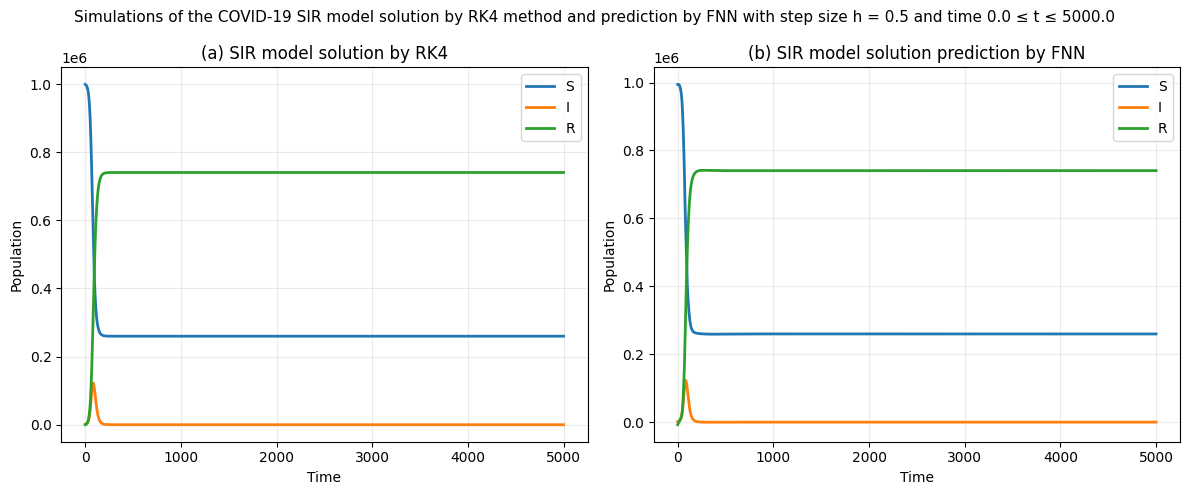

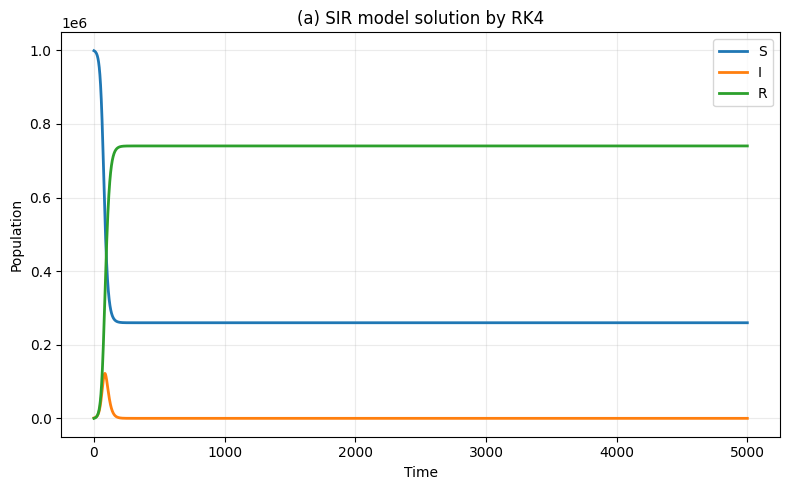

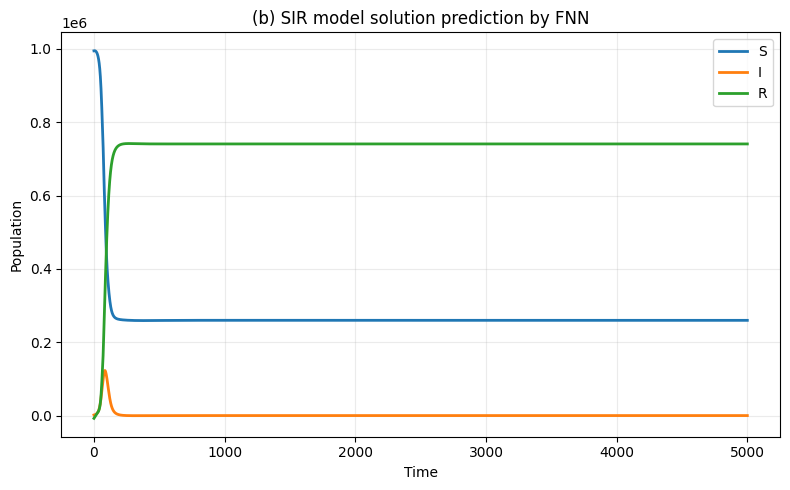

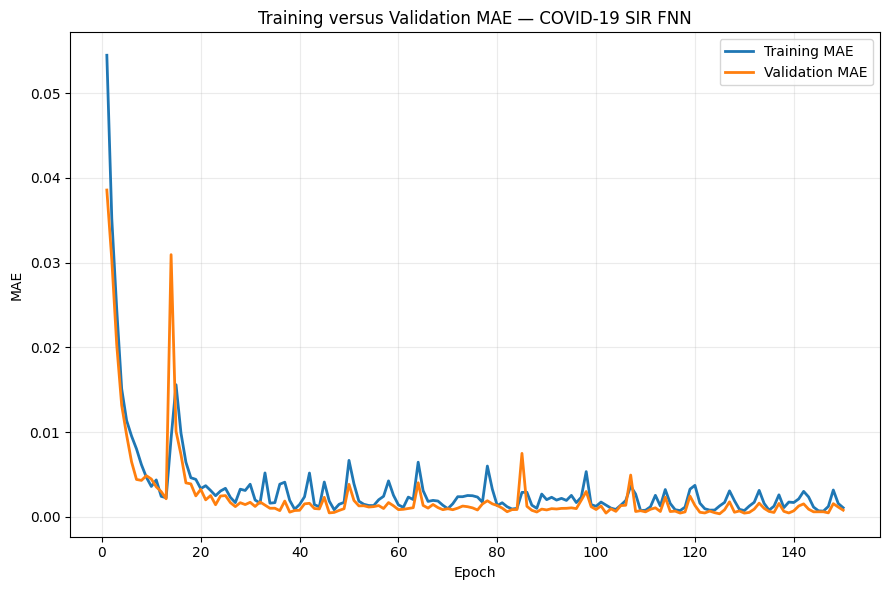

/tmp/ipykernel_95/3891556176.py:113: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(w,'RK4_Data',index=False); res.to_excel(w,'RK4_vs_FNN',index=False); metrics.to_excel(w,'Metrics',index=False); normdf.to_excel(w,'Normalized_Accuracy',index=False); Hdf.to_excel(w,'Training_History',index=False); params.to_excel(w,'Parameters',index=False)



DONE
beta=0.17150948, gamma=0.09425424, beta/gamma=1.819647
Initial state: S0=999,000, I0=1,000, R0=0, N=1,000,000
RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment        MAE          MSE        RMSE       R2
          S 237.904765 1.467337e+06 1211.336959 0.999787
          I 160.975846 6.749455e+04  259.797130 0.999459
          R 521.109094 1.583646e+06 1258.430016 0.999799

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.000322        0.000003              99.967817
          I        0.001282        0.000004              99.871751
          R        0.000689        0.000003              99.931056

Outputs: /kaggle/working/COVID19_SIR_RK4_FNN_synthetic_article_method


In [3]:
# ============================================================
# COVID-19 SIR RK4-FNN synthetic experiment
# Method follows the supplied article: RK4-generated data,
# min-max scaling, 80/20 train-validation split, FNN input=t,
# output=[S(t),I(t),R(t)], MSE loss, Adam, tanh, 150 epochs.
# ============================================================

OUT = Path('/kaggle/working/COVID19_SIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)

BETA = 0.17150948
GAMMA = 0.09425424
S0, I0, R0 = 999000.0, 1000.0, 0.0   # edit if desired
N = S0 + I0 + R0
T0, T1, H = 0.0, 5000.0, 0.5
SEED = 42
EPOCHS, BATCH_SIZE = 150, 32
HIDDEN = [16, 128, 80, 40, 16]  # published best SIR configuration

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
try: tf.config.experimental.enable_op_determinism()
except Exception: pass

# -------------------- SIR equations ---------------------------
def rhs(t, y):
    S, I, R = y
    return np.array([-BETA*S*I/N, BETA*S*I/N-GAMMA*I, GAMMA*I])

def rk4_step(t, y, h):
    k1 = h*rhs(t, y)
    k2 = h*rhs(t+h/2, y+k1/2)
    k3 = h*rhs(t+h/2, y+k2/2)
    k4 = h*rhs(t+h, y+k3)
    return np.maximum(y+(k1+2*k2+2*k3+k4)/6, 0.0)

# -------------------- RK4 synthetic data -----------------------
t = np.arange(T0, T1+H/2, H)
t[-1] = T1
y = np.zeros((len(t),3)); y[0] = [S0,I0,R0]
for j in range(len(t)-1): y[j+1] = rk4_step(t[j], y[j], H)

rk4 = pd.DataFrame({'t':t,'S_RK4':y[:,0],'I_RK4':y[:,1],'R_RK4':y[:,2]})
rk4['Total_RK4'] = rk4[['S_RK4','I_RK4','R_RK4']].sum(axis=1)
rk4.to_csv(OUT/'COVID19_SIR_RK4_synthetic_data.csv', index=False)

# -------------------- Article-style FNN ------------------------
# Article maps time t -> S,I,R (not state(t)->state(t+h)).
X, Y = t.reshape(-1,1), y.copy()
xsc, ysc = MinMaxScaler(), MinMaxScaler()
Xs, Ys = xsc.fit_transform(X), ysc.fit_transform(Y)
Xtr, Xva, Ytr, Yva = train_test_split(Xs, Ys, test_size=.20, random_state=SEED, shuffle=True)

model = keras.Sequential([layers.Input((1,))] +
    [layers.Dense(u, activation='tanh') for u in HIDDEN] +
    [layers.Dense(3, activation='linear')], name='COVID19_SIR_FNN')
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
print(model.summary())
hist = model.fit(Xtr, Ytr, validation_data=(Xva,Yva), epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=1)

Hdf = pd.DataFrame(hist.history); Hdf.insert(0,'epoch',np.arange(1,len(Hdf)+1)); Hdf.to_csv(OUT/'FNN_training_history.csv',index=False)

# Full-domain FNN prediction, as in article tables/figure
pred = ysc.inverse_transform(model.predict(Xs,batch_size=BATCH_SIZE,verbose=1))
Sfnn, Ifnn, Rfnn = pred.T

# Raw network predictions are retained; optional nonnegative version is used for plots/metrics.
Sfnn = np.maximum(Sfnn,0); Ifnn=np.maximum(Ifnn,0); Rfnn=np.maximum(Rfnn,0)

res = pd.DataFrame({'t':t,'S_RK4':y[:,0],'I_RK4':y[:,1],'R_RK4':y[:,2],
                    'S_FNN':Sfnn,'I_FNN':Ifnn,'R_FNN':Rfnn})
res['RK4_Total']=res[['S_RK4','I_RK4','R_RK4']].sum(axis=1)
res['FNN_Total']=res[['S_FNN','I_FNN','R_FNN']].sum(axis=1)
res['FNN_Total_Error']=res['FNN_Total']-N
res.to_csv(OUT/'COVID19_SIR_RK4_vs_FNN_complete.csv',index=False)

# -------------------- Metrics ----------------------------------
rows=[]
for k,name in enumerate(['S','I','R']):
    a,p=y[:,k],pred[:,k]
    rows.append({'Compartment':name,'MAE':mean_absolute_error(a,p),
                 'MSE':mean_squared_error(a,p),'RMSE':np.sqrt(mean_squared_error(a,p)),
                 'R2':r2_score(a,p)})
metrics=pd.DataFrame(rows); metrics.to_csv(OUT/'COVID19_SIR_RK4_FNN_metrics.csv',index=False)

# Article-style normalized MAE and accuracy-like score
norm=[]
Pscaled=ysc.transform(np.column_stack([Sfnn,Ifnn,Rfnn]))
for k,name in enumerate(['S','I','R']):
    mae=mean_absolute_error(Ys[:,k],Pscaled[:,k])
    norm.append({'Compartment':name,'Normalized_MAE':mae,'Normalized_MSE':mean_squared_error(Ys[:,k],Pscaled[:,k]),'Accuracy_like_percent':(1-mae)*100})
normdf=pd.DataFrame(norm); normdf.to_csv(OUT/'COVID19_SIR_FNN_normalized_accuracy.csv',index=False)

# -------------------- Figure 2 style ---------------------------
fig, ax = plt.subplots(1,2,figsize=(12,5))
for a, data, title in [(ax[0],y,'(a) SIR model solution by RK4'),(ax[1],pred,'(b) SIR model solution prediction by FNN')]:
    a.plot(t,data[:,0],label='S',linewidth=2); a.plot(t,data[:,1],label='I',linewidth=2); a.plot(t,data[:,2],label='R',linewidth=2)
    a.set_title(title); a.set_xlabel('Time'); a.set_ylabel('Population'); a.legend(); a.grid(alpha=.25)
fig.suptitle(f'Simulations of the COVID-19 SIR model solution by RK4 method and prediction by FNN with step size h = {H} and time {T0} ≤ t ≤ {T1}',fontsize=11)
fig.tight_layout(); fig.savefig(OUT/'Figure2_COVID19_SIR_RK4_vs_FNN.png',dpi=300,bbox_inches='tight'); plt.show()

# Individual panels
for data,title,file in [(y,'(a) SIR model solution by RK4','Figure2a_RK4_SIR.png'),(pred,'(b) SIR model solution prediction by FNN','Figure2b_FNN_SIR.png')]:
    plt.figure(figsize=(8,5)); plt.plot(t,data[:,0],label='S',lw=2); plt.plot(t,data[:,1],label='I',lw=2); plt.plot(t,data[:,2],label='R',lw=2); plt.title(title); plt.xlabel('Time'); plt.ylabel('Population'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(OUT/file,dpi=300,bbox_inches='tight'); plt.show()

# Figure 4 style training/validation MAE
plt.figure(figsize=(9,6)); plt.plot(Hdf.epoch,Hdf.mae,label='Training MAE',lw=2); plt.plot(Hdf.epoch,Hdf.val_mae,label='Validation MAE',lw=2); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.title('Training versus Validation MAE — COVID-19 SIR FNN'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(OUT/'Figure4_style_training_validation_MAE.png',dpi=300,bbox_inches='tight'); plt.show()

# -------------------- Excel ------------------------------------
params=pd.DataFrame({'Parameter':['Beta','Gamma','beta/gamma','S0','I0','R0','N','Time_start','Time_end','Step_h','Samples','FNN_input','FNN_output','Normalization','Train','Validation','Random_state','Activation','Optimizer','Hidden_layers','Epochs','Batch_size'],
                     'Value':[BETA,GAMMA,BETA/GAMMA,S0,I0,R0,N,T0,T1,H,len(t),'t','S(t), I(t), R(t)','Min-Max [0,1]','80%','20%',SEED,'tanh','Adam',str(HIDDEN),EPOCHS,BATCH_SIZE]})
with pd.ExcelWriter(OUT/'COVID19_SIR_RK4_FNN_complete_results.xlsx',engine='openpyxl') as w:
    rk4.to_excel(w,'RK4_Data',index=False); res.to_excel(w,'RK4_vs_FNN',index=False); metrics.to_excel(w,'Metrics',index=False); normdf.to_excel(w,'Normalized_Accuracy',index=False); Hdf.to_excel(w,'Training_History',index=False); params.to_excel(w,'Parameters',index=False)
model.save(OUT/'COVID19_SIR_FNN.keras')

print('\n'+'='*75); print('DONE'); print('='*75)
print(f'beta={BETA:.8f}, gamma={GAMMA:.8f}, beta/gamma={BETA/GAMMA:.6f}')
print(f'Initial state: S0={S0:,.0f}, I0={I0:,.0f}, R0={R0:,.0f}, N={N:,.0f}')
print(f'RK4: h={H}, t=[{T0},{T1}], samples={len(t):,}')
print('\nMetrics (FNN vs RK4):'); print(metrics.to_string(index=False))
print('\nNormalized accuracy-like score:'); print(normdf.to_string(index=False))
print('\nOutputs:', OUT)

Model: "COVID19_SEIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,492 (64.42 KB)

 Trainable params: 16,492 (64.42 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/150
244/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0356 - mae: 0.0970

2026-09-03 06:25:52.540154: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0180 - mae: 0.0606 - val_loss: 0.0121 - val_mae: 0.0441
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084 - mae: 0.0377 - val_loss: 0.0066 - val_mae: 0.0294
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - mae: 0.0227 - val_loss: 0.0039 - val_mae: 0.0188
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - mae: 0.0159 - val_loss: 0.0019 - val_mae: 0.0146
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - mae: 0.0111 - val_loss: 0.0014 - val_mae: 0.0136
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.5927e-04 - mae: 0.0090 - val_loss: 2.4520e-04 - val_mae: 0.0063
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1409e-04 - mae: 0.0058 - val_loss: 3.8072e-04 - val_mae: 0.0078
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.0923e-04 - mae: 0.0066 - val_loss: 0.0022 - val_mae: 0.0162
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━

2026-09-03 06:27:40.705548: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


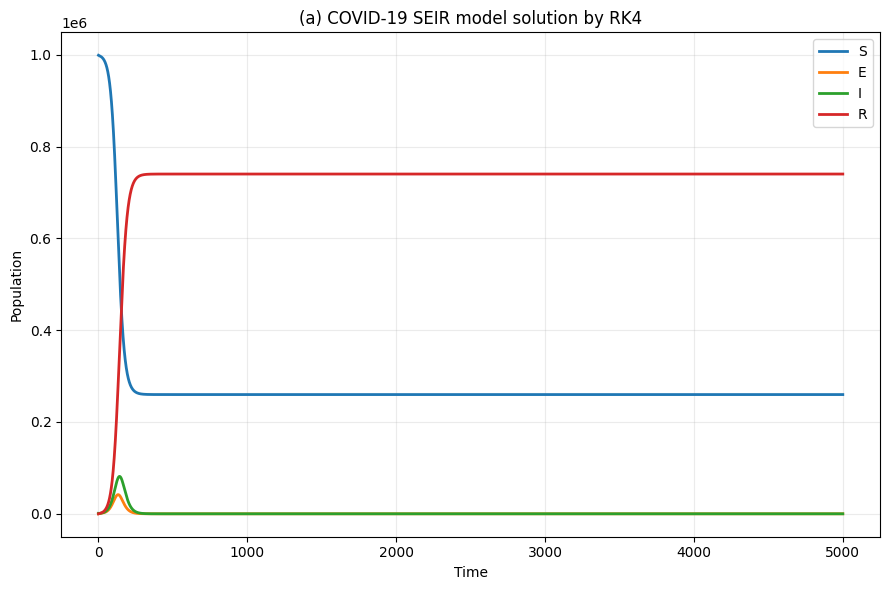

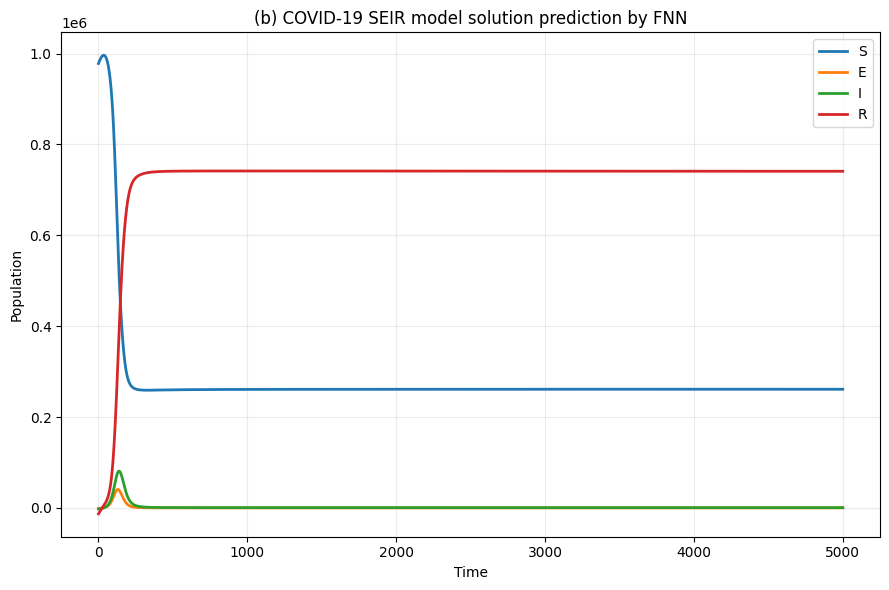

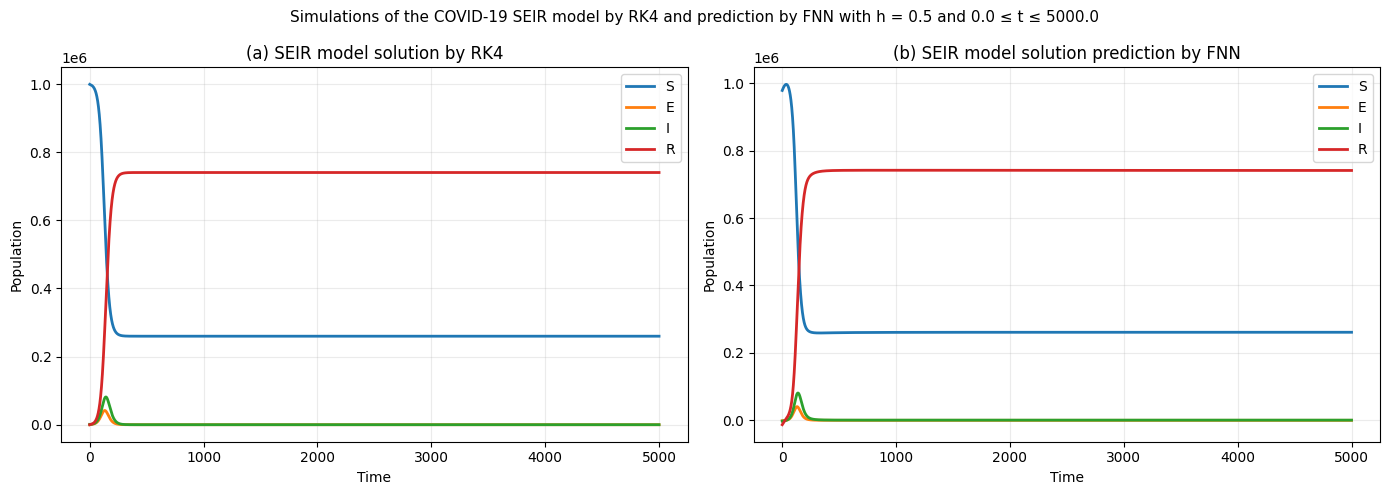

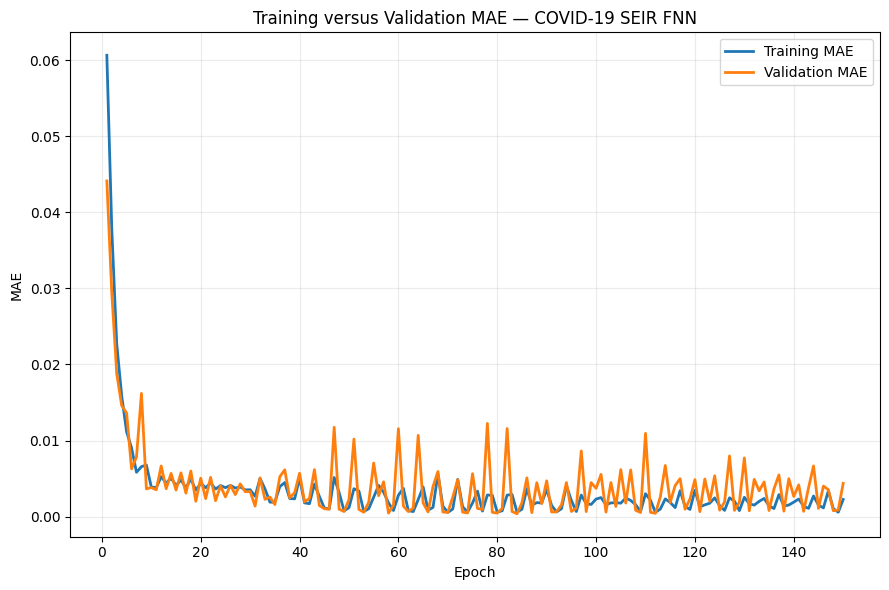

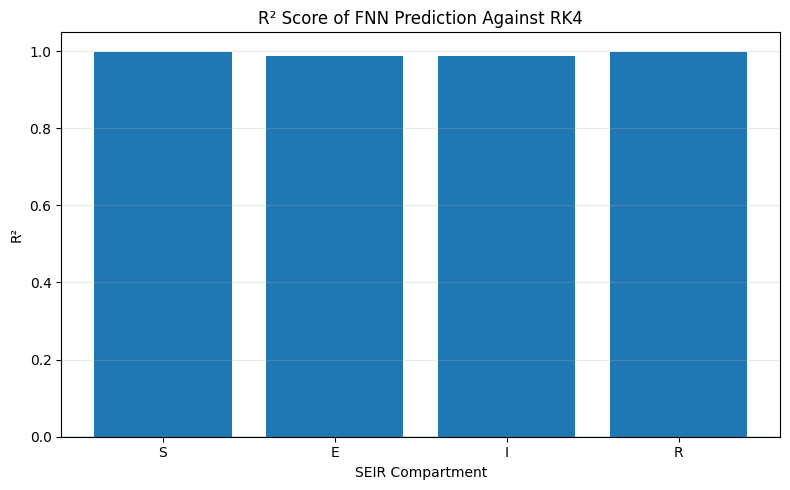

/tmp/ipykernel_95/4186797239.py:1038: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(
/tmp/ipykernel_95/4186797239.py:1044: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  res.to_excel(
/tmp/ipykernel_95/4186797239.py:1050: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  metrics.to_excel(
/tmp/ipykernel_95/4186797239.py:1056: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  normdf.to_excel(
/tmp/ipykernel_95/4186797239.py:1062: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  Hdf.to_excel(
/tmp/ipykernel_95/4186797239.py:1068: FutureWarn


COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED
beta = 0.17150948
gamma = 0.09425424
sigma = 0.19230769
latent period = 5.20 days
beta/gamma = 1.819647

Initial state: S0=999,000, E0=0, I0=1,000, R0=0
N = 1,000,000

RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment         MAE          MSE        RMSE       R2
          S 1940.653667 1.681622e+07 4100.758428 0.998510
          E  134.361332 2.843884e+05  533.280822 0.986281
          I  692.519063 1.022104e+06 1010.991575 0.987683
          R 1964.095479 3.729509e+07 6106.970383 0.997090

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.002625        0.000031              99.737476
          E        0.003099        0.000156              99.690129
          I        0.008374        0.000147              99.162568
          R        0.002609        0.000067              99.739074

Population conservation check:
RK4 maximum absolute error = 0

In [4]:
# ============================================================
# Output directory
# ============================================================

OUT = Path('/kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)


# ============================================================
# SEIR PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

# Sigma = rate at which exposed individuals become infectious
# Mean latent/incubation period = 1 / SIGMA
SIGMA = 1.0 / 5.2

# Initial conditions
S0 = 999000.0
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population
N = S0 + E0 + I0 + R0


# ============================================================
# TIME SETTINGS
# ============================================================

T0 = 0.0
T1 = 5000.0
H = 0.5


# ============================================================
# FNN SETTINGS
# ============================================================

SEED = 42

EPOCHS = 150
BATCH_SIZE = 32

# Same published-style architecture as your SIR code
HIDDEN = [16, 128, 80, 40, 16]


# ============================================================
# RANDOM SEED
# ============================================================

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ============================================================
# SEIR DIFFERENTIAL EQUATIONS
# ============================================================
#
# dS/dt = -beta*S*I/N
#
# dE/dt = beta*S*I/N - sigma*E
#
# dI/dt = sigma*E - gamma*I
#
# dR/dt = gamma*I
#
# ============================================================

def rhs(t, y):

    S, E, I, R = y

    dS = -BETA * S * I / N

    dE = BETA * S * I / N - SIGMA * E

    dI = SIGMA * E - GAMMA * I

    dR = GAMMA * I

    return np.array([dS, dE, dI, dR])


# ============================================================
# RK4 ONE STEP
# ============================================================

def rk4_step(t, y, h):

    k1 = h * rhs(t, y)

    k2 = h * rhs(
        t + h / 2,
        y + k1 / 2
    )

    k3 = h * rhs(
        t + h / 2,
        y + k2 / 2
    )

    k4 = h * rhs(
        t + h,
        y + k3
    )

    y_next = y + (
        k1 + 2*k2 + 2*k3 + k4
    ) / 6

    # Avoid negative populations
    y_next = np.maximum(y_next, 0.0)

    return y_next


# ============================================================
# GENERATE TIME ARRAY
# ============================================================

t = np.arange(
    T0,
    T1 + H / 2,
    H
)

t[-1] = T1


# ============================================================
# RK4 SYNTHETIC DATA GENERATION
# ============================================================

y = np.zeros(
    (len(t), 4)
)

# Initial conditions
y[0] = [
    S0,
    E0,
    I0,
    R0
]


# Run RK4
for j in range(len(t) - 1):

    y[j + 1] = rk4_step(
        t[j],
        y[j],
        H
    )


# ============================================================
# CREATE RK4 DATAFRAME
# ============================================================

rk4 = pd.DataFrame({
    't': t,
    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3]
})


# Total population
rk4['Total_RK4'] = rk4[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


# Population conservation error
rk4['Population_Error'] = (
    rk4['Total_RK4'] - N
)


# Save RK4 synthetic dataset
rk4.to_csv(
    OUT / 'COVID19_SEIR_RK4_synthetic_data.csv',
    index=False
)


# ============================================================
# ARTICLE-STYLE FNN
# ============================================================
#
# Input:
#       t
#
# Output:
#       S(t), E(t), I(t), R(t)
#
# ============================================================

X = t.reshape(-1, 1)

Y = y.copy()


# ============================================================
# MIN-MAX NORMALIZATION
# ============================================================

xsc = MinMaxScaler()

ysc = MinMaxScaler()


Xs = xsc.fit_transform(X)

Ys = ysc.fit_transform(Y)


# ============================================================
# 80/20 TRAIN-VALIDATION SPLIT
# ============================================================

Xtr, Xva, Ytr, Yva = train_test_split(
    Xs,
    Ys,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)


# ============================================================
# BUILD FNN
# ============================================================

model = keras.Sequential(
    [
        layers.Input((1,))
    ]
    +
    [
        layers.Dense(
            u,
            activation='tanh'
        )
        for u in HIDDEN
    ]
    +
    [
        layers.Dense(
            4,
            activation='linear'
        )
    ],
    name='COVID19_SEIR_FNN'
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(
            name='mae'
        )
    ]
)


print(model.summary())


# ============================================================
# TRAIN FNN
# ============================================================

hist = model.fit(
    Xtr,
    Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


# ============================================================
# TRAINING HISTORY
# ============================================================

Hdf = pd.DataFrame(
    hist.history
)

Hdf.insert(
    0,
    'epoch',
    np.arange(
        1,
        len(Hdf) + 1
    )
)


Hdf.to_csv(
    OUT / 'FNN_training_history.csv',
    index=False
)


# ============================================================
# FULL-DOMAIN FNN PREDICTION
# ============================================================

pred_scaled = model.predict(
    Xs,
    batch_size=BATCH_SIZE,
    verbose=1
)


# Convert back to original population scale
pred = ysc.inverse_transform(
    pred_scaled
)


# ============================================================
# EXTRACT COMPARTMENTS
# ============================================================

Sfnn = pred[:, 0]
Efnn = pred[:, 1]
Ifnn = pred[:, 2]
Rfnn = pred[:, 3]


# Optional non-negative predictions
Sfnn = np.maximum(
    Sfnn,
    0
)

Efnn = np.maximum(
    Efnn,
    0
)

Ifnn = np.maximum(
    Ifnn,
    0
)

Rfnn = np.maximum(
    Rfnn,
    0
)


# ============================================================
# RESULTS DATAFRAME
# ============================================================

res = pd.DataFrame({

    't': t,

    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3],

    'S_FNN': Sfnn,
    'E_FNN': Efnn,
    'I_FNN': Ifnn,
    'R_FNN': Rfnn
})


# ============================================================
# TOTAL POPULATION
# ============================================================

res['RK4_Total'] = res[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


res['FNN_Total'] = res[
    [
        'S_FNN',
        'E_FNN',
        'I_FNN',
        'R_FNN'
    ]
].sum(axis=1)


# ============================================================
# FNN TOTAL POPULATION ERROR
# ============================================================

res['FNN_Total_Error'] = (
    res['FNN_Total'] - N
)


# ============================================================
# COMPARTMENT-WISE ERRORS
# ============================================================

res['S_Error'] = (
    res['S_FNN'] - res['S_RK4']
)

res['E_Error'] = (
    res['E_FNN'] - res['E_RK4']
)

res['I_Error'] = (
    res['I_FNN'] - res['I_RK4']
)

res['R_Error'] = (
    res['R_FNN'] - res['R_RK4']
)


# Save complete results
res.to_csv(
    OUT / 'COVID19_SEIR_RK4_vs_FNN_complete.csv',
    index=False
)


# ============================================================
# METRICS
# ============================================================

rows = []


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    actual = y[:, k]

    prediction = pred[:, k]


    mse = mean_squared_error(
        actual,
        prediction
    )


    rows.append({

        'Compartment': name,

        'MAE': mean_absolute_error(
            actual,
            prediction
        ),

        'MSE': mse,

        'RMSE': np.sqrt(mse),

        'R2': r2_score(
            actual,
            prediction
        )

    })


metrics = pd.DataFrame(
    rows
)


metrics.to_csv(
    OUT / 'COVID19_SEIR_RK4_FNN_metrics.csv',
    index=False
)


# ============================================================
# NORMALIZED MAE / ACCURACY-LIKE SCORE
# ============================================================

norm = []


# Use non-negative predictions for this section
P_for_scaling = np.column_stack(
    [
        Sfnn,
        Efnn,
        Ifnn,
        Rfnn
    ]
)


Pscaled = ysc.transform(
    P_for_scaling
)


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    mae = mean_absolute_error(
        Ys[:, k],
        Pscaled[:, k]
    )

    mse = mean_squared_error(
        Ys[:, k],
        Pscaled[:, k]
    )


    norm.append({

        'Compartment': name,

        'Normalized_MAE': mae,

        'Normalized_MSE': mse,

        'Accuracy_like_percent':
            (1 - mae) * 100

    })


normdf = pd.DataFrame(
    norm
)


normdf.to_csv(
    OUT / 'COVID19_SEIR_FNN_normalized_accuracy.csv',
    index=False
)


# ============================================================
# FIGURE 1
# RK4 SEIR SOLUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(a) COVID-19 SEIR model solution by RK4'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_RK4_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 2
# FNN SEIR PREDICTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(b) COVID-19 SEIR model solution prediction by FNN'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 3
# RK4 VS FNN — SIDE BY SIDE
# ============================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# RK4
# ------------------------------------------------------------

ax[0].plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


ax[0].set_title(
    '(a) SEIR model solution by RK4'
)

ax[0].set_xlabel('Time')

ax[0].set_ylabel('Population')

ax[0].legend()

ax[0].grid(alpha=0.25)


# ------------------------------------------------------------
# FNN
# ------------------------------------------------------------

ax[1].plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


ax[1].set_title(
    '(b) SEIR model solution prediction by FNN'
)

ax[1].set_xlabel('Time')

ax[1].set_ylabel('Population')

ax[1].legend()

ax[1].grid(alpha=0.25)


fig.suptitle(
    f'Simulations of the COVID-19 SEIR model '
    f'by RK4 and prediction by FNN '
    f'with h = {H} and '
    f'{T0} ≤ t ≤ {T1}',
    fontsize=11
)


fig.tight_layout()


fig.savefig(
    OUT / 'Figure_RK4_vs_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 4
# TRAINING VS VALIDATION MAE
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    Hdf.epoch,
    Hdf.mae,
    label='Training MAE',
    linewidth=2
)

plt.plot(
    Hdf.epoch,
    Hdf.val_mae,
    label='Validation MAE',
    linewidth=2
)


plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.title(
    'Training versus Validation MAE — COVID-19 SEIR FNN'
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_Training_Validation_MAE_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 5
# R2 BAR CHART
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    metrics['Compartment'],
    metrics['R2']
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel('SEIR Compartment')

plt.ylabel('R²')

plt.title(
    'R² Score of FNN Prediction Against RK4'
)

plt.grid(
    axis='y',
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_R2_SEIR_FNN.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# EXCEL OUTPUT
# ============================================================

params = pd.DataFrame({

    'Parameter': [

        'Beta',
        'Gamma',
        'Sigma',
        '1/Sigma',
        'Beta/Gamma',

        'S0',
        'E0',
        'I0',
        'R0',

        'N',

        'Time_start',
        'Time_end',

        'Step_h',

        'Samples',

        'FNN_input',

        'FNN_output',

        'Normalization',

        'Train',

        'Validation',

        'Random_state',

        'Activation',

        'Optimizer',

        'Hidden_layers',

        'Epochs',

        'Batch_size'

    ],


    'Value': [

        BETA,
        GAMMA,
        SIGMA,
        1 / SIGMA,
        BETA / GAMMA,

        S0,
        E0,
        I0,
        R0,

        N,

        T0,
        T1,

        H,

        len(t),

        't',

        'S(t), E(t), I(t), R(t)',

        'Min-Max [0,1]',

        '80%',

        '20%',

        SEED,

        'tanh',

        'Adam',

        str(HIDDEN),

        EPOCHS,

        BATCH_SIZE

    ]

})


with pd.ExcelWriter(
    OUT / 'COVID19_SEIR_RK4_FNN_complete_results.xlsx',
    engine='openpyxl'
) as writer:

    rk4.to_excel(
        writer,
        'RK4_Data',
        index=False
    )

    res.to_excel(
        writer,
        'RK4_vs_FNN',
        index=False
    )

    metrics.to_excel(
        writer,
        'Metrics',
        index=False
    )

    normdf.to_excel(
        writer,
        'Normalized_Accuracy',
        index=False
    )

    Hdf.to_excel(
        writer,
        'Training_History',
        index=False
    )

    params.to_excel(
        writer,
        'Parameters',
        index=False
    )


# ============================================================
# SAVE MODEL
# ============================================================

model.save(
    OUT / 'COVID19_SEIR_FNN.keras'
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print('\n' + '=' * 80)

print('COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED')

print('=' * 80)


print(
    f'beta = {BETA:.8f}'
)

print(
    f'gamma = {GAMMA:.8f}'
)

print(
    f'sigma = {SIGMA:.8f}'
)

print(
    f'latent period = {1/SIGMA:.2f} days'
)

print(
    f'beta/gamma = {BETA/GAMMA:.6f}'
)


print(
    f'\nInitial state: '
    f'S0={S0:,.0f}, '
    f'E0={E0:,.0f}, '
    f'I0={I0:,.0f}, '
    f'R0={R0:,.0f}'
)


print(
    f'N = {N:,.0f}'
)


print(
    f'\nRK4: h={H}, '
    f't=[{T0},{T1}], '
    f'samples={len(t):,}'
)


print(
    '\nMetrics (FNN vs RK4):'
)

print(
    metrics.to_string(
        index=False
    )
)


print(
    '\nNormalized accuracy-like score:'
)

print(
    normdf.to_string(
        index=False
    )
)


print(
    '\nPopulation conservation check:'
)

print(
    f'RK4 maximum absolute error = '
    f'{np.max(np.abs(rk4["Population_Error"])):.10f}'
)


print(
    '\nOutputs saved to:'
)

print(
    OUT
)

print('=' * 80)

# Synthetic data generation for SIR model using RK4

In [5]:
import numpy as np
import pandas as pd


# ============================================================
# SIR MODEL
# ============================================================

def sir_derivatives(t, y, beta, gamma, N):

    S, I, R = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return np.array([
        dSdt,
        dIdt,
        dRdt
    ])


# ============================================================
# RK4 SOLVER
# ============================================================

def rk4_sir(t0, t_end, h, S0, I0, R0, beta, gamma):

    N = S0 + I0 + R0

    num_steps = int(round((t_end - t0) / h))

    t_values = np.zeros(num_steps + 1)
    solution = np.zeros((num_steps + 1, 3))

    t_values[0] = t0
    solution[0] = [S0, I0, R0]

    for n in range(num_steps):

        t = t_values[n]
        y = solution[n]

        # k1
        k1 = sir_derivatives(
            t,
            y,
            beta,
            gamma,
            N
        )

        # k2
        k2 = sir_derivatives(
            t + h / 2,
            y + h * k1 / 2,
            beta,
            gamma,
            N
        )

        # k3
        k3 = sir_derivatives(
            t + h / 2,
            y + h * k2 / 2,
            beta,
            gamma,
            N
        )

        # k4
        k4 = sir_derivatives(
            t + h,
            y + h * k3,
            beta,
            gamma,
            N
        )

        # RK4 update
        solution[n + 1] = (
            y +
            (h / 6) *
            (k1 + 2*k2 + 2*k3 + k4)
        )

        t_values[n + 1] = t + h

    return t_values, solution


# ============================================================
# PARAMETERS
# ============================================================

# Initial conditions
S0 = 999000.0
I0 = 1000.0
R0 = 0.0

# SIR parameters
BETA = 0.17150948
GAMMA = 0.09425424


# ============================================================
# TIME SETTINGS
# ============================================================

T0 = 0.0
T1 = 5000.0
H = 0.5


# ============================================================
# RUN RK4
# ============================================================

t, sir = rk4_sir(
    T0,
    T1,
    H,
    S0,
    I0,
    R0,
    BETA,
    GAMMA
)


# ============================================================
# EXTRACT S, I, R
# ============================================================

S = sir[:, 0]
I = sir[:, 1]
R = sir[:, 2]


# ============================================================
# CREATE TABLE
# ============================================================

sir_table = pd.DataFrame({
    "t": t,
    "S": S,
    "I": I,
    "R": R
})


# ============================================================
# DISPLAY SELECTED ROWS
# ============================================================

selected_indices = [
    0,
    1,
    2,
    3,
    4,
    len(t) - 3,
    len(t) - 2,
    len(t) - 1
]

print("\nTable 6. SIR model solution obtained by RK4")
print("=" * 75)

print(
    f"{'t':>10}"
    f"{'S':>18}"
    f"{'I':>18}"
    f"{'R':>18}"
)

for i in selected_indices:

    print(
        f"{t[i]:10.3f}"
        f"{S[i]:18.3f}"
        f"{I[i]:18.3f}"
        f"{R[i]:18.3f}"
    )


Table 6. SIR model solution obtained by RK4
         t                 S                 I                 R
     0.000        999000.000          1000.000             0.000
     0.500        998912.663          1039.290            48.047
     1.000        998821.902          1080.116            97.982
     1.500        998727.585          1122.537           149.878
     2.000        998629.574          1166.614           203.812
  4999.000        259770.286             0.000        740229.714
  4999.500        259770.286             0.000        740229.714
  5000.000        259770.286             0.000        740229.714


# Synthetic data generation for SEIR model using RK4

In [6]:
# ============================================================
# SEIR MODEL
# ============================================================

def seir_derivatives(t, y, beta, gamma, sigma, N):

    S, E, I, R = y

    infection = beta * S * I / N

    dSdt = -infection
    dEdt = infection - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I

    return np.array([
        dSdt,
        dEdt,
        dIdt,
        dRdt
    ])


# ============================================================
# RK4 SEIR
# ============================================================

def rk4_seir(
    t0,
    t_end,
    h,
    S0,
    E0,
    I0,
    R0,
    beta,
    gamma,
    sigma
):

    N = S0 + E0 + I0 + R0

    num_steps = int(round((t_end - t0) / h))

    t_values = np.zeros(num_steps + 1)

    solution = np.zeros(
        (num_steps + 1, 4)
    )

    t_values[0] = t0

    solution[0] = [
        S0,
        E0,
        I0,
        R0
    ]

    for n in range(num_steps):

        t = t_values[n]
        y = solution[n]

        k1 = seir_derivatives(
            t, y, beta, gamma, sigma, N
        )

        k2 = seir_derivatives(
            t + h/2,
            y + h*k1/2,
            beta, gamma, sigma, N
        )

        k3 = seir_derivatives(
            t + h/2,
            y + h*k2/2,
            beta, gamma, sigma, N
        )

        k4 = seir_derivatives(
            t + h,
            y + h*k3,
            beta, gamma, sigma, N
        )

        solution[n+1] = (
            y +
            h/6 * (
                k1 +
                2*k2 +
                2*k3 +
                k4
            )
        )

        t_values[n+1] = t + h

    return t_values, solution


# ============================================================
# PARAMETERS FROM TABLE 8 INITIAL CONDITIONS
# ============================================================

N = 1,000,000

S0 = 999000.0
I0 = 1000.0
R0 = 0.0
E0 = 0.0


BETA = 0.17150948
GAMMA = 0.09425424
SIGMA = 1.0 / 5.2

t0 = 0.0
t_end = 5000.0
h = 0.5



# ============================================================
# RUN SEIR
# ============================================================

t, seir = rk4_seir(
    t0,
    t_end,
    h,
    S0,
    E0,
    I0,
    R0,
    BETA,
    GAMMA,
    SIGMA
)

S = seir[:, 0]
E = seir[:, 1]
I = seir[:, 2]
R = seir[:, 3]


# ============================================================
# TABLE 8
# ============================================================

selected_indices = [
    0,
    1,
    2,
    3,
    4,
    len(t) - 3,
    len(t) - 2,
    len(t) - 1
]

print("\nTable 8. SEIR model solution obtained by RK4")
print("=" * 95)

print(
    f"{'t':>10}"
    f"{'S':>18}"
    f"{'E':>18}"
    f"{'I':>18}"
    f"{'R':>18}"
)

for i in selected_indices:

    print(
        f"{t[i]:10.4f}"
        f"{S[i]:18.4f}"
        f"{E[i]:18.4f}"
        f"{I[i]:18.4f}"
        f"{R[i]:18.4f}"
    )


Table 8. SEIR model solution obtained by RK4
         t                 S                 E                 I                 R
    0.0000       999000.0000            0.0000         1000.0000            0.0000
    0.5000       998916.2098           79.8600          957.8347           46.0955
    1.0000       998835.6455          149.3290          924.6055           90.4200
    1.5000       998757.5984          210.0344          899.0041          133.3630
    2.0000       998681.4635          263.3559          879.9235          175.2572
 4999.0000       259770.2864            0.0000            0.0000       740229.7136
 4999.5000       259770.2864            0.0000            0.0000       740229.7136
 5000.0000       259770.2864            0.0000            0.0000       740229.7136


# FNN for SIR

In [13]:
# ============================================================
# FNN FOR SIR
# ============================================================

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler


# ------------------------------------------------------------
# RK4 DATA
# ------------------------------------------------------------

X = t.reshape(-1, 1)

Y = np.column_stack([
    S,
    I,
    R
])


# ------------------------------------------------------------
# SCALE DATA
# ------------------------------------------------------------

x_scaler = MinMaxScaler()

y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X)

Y_scaled = y_scaler.fit_transform(Y)


# ------------------------------------------------------------
# FNN
# ------------------------------------------------------------

model_sir = Sequential([

    Dense(
        64,
        activation="tanh",
        input_shape=(1,)
    ),

    Dense(
        64,
        activation="tanh"
    ),

    Dense(
        64,
        activation="tanh"
    ),

    Dense(
        3,
        activation="linear"
    )
])


# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

model_sir.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

history = model_sir.fit(
    X_scaled,
    Y_scaled,
    epochs=150,
    batch_size=32,
    verbose=1,
    validation_split=0.2
)


# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

Y_pred_scaled = model_sir.predict(
    X_scaled,
    verbose=0
)

Y_pred = y_scaler.inverse_transform(
    Y_pred_scaled
)


SIR_FNN_pred_S = Y_pred[:, 0]
SIR_FNN_pred_I = Y_pred[:, 1]
SIR_FNN_pred_R = Y_pred[:, 2]


# ------------------------------------------------------------
# TABLE 9
# ------------------------------------------------------------

print("\nTable 9. Predicted values of S, I, and R by FNN")
print("=" * 85)

print(
    f"{'t':>10}"
    f"{'Predicted S':>22}"
    f"{'Predicted I':>22}"
    f"{'Predicted R':>22}"
)

for i in selected_indices:

    print(
        f"{t[i]:10.3f}"
        f"{SIR_FNN_pred_S[i]:22.3f}"
        f"{SIR_FNN_pred_I[i]:22.3f}"
        f"{SIR_FNN_pred_R[i]:22.3f}"
    )

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


232/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0573

2026-09-03 06:44:58.283500: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0240 - val_loss: 0.0017
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0137 - val_loss: 0.0016
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0136 - val_loss: 0.0018
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0129 - val_loss: 7.4748e-04
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0108 - val_loss: 0.0026
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0075 - val_loss: 1.6821e-04
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0047 - val_loss: 1.3620e-04
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - val_loss: 4.5439e-05
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0028 - val_loss: 1.2753e-04
Epoch 10/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0026 - val_loss: 5.9631e-05
Epoch 11/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0024 - val_loss: 1.2445e-05
Epoch 12/150
250/250 ━━━━

2026-09-03 06:46:28.566216: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Table 9. Predicted values of S, I, and R by FNN
         t           Predicted S           Predicted I           Predicted R
     0.000            988878.938              1518.786            -14426.002
     0.500            989198.562              1539.208            -13832.026
     1.000            989511.312              1561.125            -13240.163
     1.500            989817.125              1584.638            -12650.562
     2.000            990115.438              1609.784            -12063.133
  4999.000            258860.953              -106.088            739457.312
  4999.500            258860.797              -106.088            739457.500
  5000.000            258860.641              -106.084            739457.438


# FNN fir SIR model evaluation

## Create RK4 reference-data

In [14]:
import numpy as np
import pandas as pd

# ============================================================
# SIR MODEL PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

S0 = 999000.0
I0 = 1000.0
R0 = 0.0

N = S0 + I0 + R0

# Time settings
t_start = 0.0
t_end = 5000.0
h = 0.5


# ============================================================
# SIR DIFFERENTIAL EQUATIONS
# ============================================================

def sir_derivatives(S, I, R):

    dSdt = -BETA * S * I / N

    dIdt = BETA * S * I / N - GAMMA * I

    dRdt = GAMMA * I

    return dSdt, dIdt, dRdt


# ============================================================
# RK4 SIMULATION
# ============================================================

num_steps = int((t_end - t_start) / h)

t_values = np.linspace(
    t_start,
    t_end,
    num_steps + 1
)

S = np.zeros(num_steps + 1)
I = np.zeros(num_steps + 1)
R = np.zeros(num_steps + 1)

# Initial conditions
S[0] = S0
I[0] = I0
R[0] = R0


# ============================================================
# RK4 LOOP
# ============================================================

for n in range(num_steps):

    # Current values
    S_n = S[n]
    I_n = I[n]
    R_n = R[n]

    # k1
    k1_S, k1_I, k1_R = sir_derivatives(
        S_n, I_n, R_n
    )

    # k2
    k2_S, k2_I, k2_R = sir_derivatives(
        S_n + h*k1_S/2,
        I_n + h*k1_I/2,
        R_n + h*k1_R/2
    )

    # k3
    k3_S, k3_I, k3_R = sir_derivatives(
        S_n + h*k2_S/2,
        I_n + h*k2_I/2,
        R_n + h*k2_R/2
    )

    # k4
    k4_S, k4_I, k4_R = sir_derivatives(
        S_n + h*k3_S,
        I_n + h*k3_I,
        R_n + h*k3_R
    )

    # Update
    S[n+1] = S_n + (h/6) * (
        k1_S + 2*k2_S + 2*k3_S + k4_S
    )

    I[n+1] = I_n + (h/6) * (
        k1_I + 2*k2_I + 2*k3_I + k4_I
    )

    R[n+1] = R_n + (h/6) * (
        k1_R + 2*k2_R + 2*k3_R + k4_R
    )


# ============================================================
# SAVE RK4 REFERENCE DATA
# ============================================================

rk4_reference = pd.DataFrame({
    "t": t_values,
    "S_RK4": S,
    "I_RK4": I,
    "R_RK4": R
})

print(rk4_reference.head())
print(rk4_reference.tail())

     t          S_RK4        I_RK4       R_RK4
0  0.0  999000.000000  1000.000000    0.000000
1  0.5  998912.662606  1039.290370   48.047024
2  1.0  998821.902132  1080.116226   97.981642
3  1.5  998727.585478  1122.536914  149.877608
4  2.0  998629.574455  1166.614021  203.811524
            t          S_RK4          I_RK4          R_RK4
9996   4998.0  259770.286373  3.014095e-101  740229.713627
9997   4998.5  259770.286373  2.940116e-101  740229.713627
9998   4999.0  259770.286373  2.867953e-101  740229.713627
9999   4999.5  259770.286373  2.797561e-101  740229.713627
10000  5000.0  259770.286373  2.728896e-101  740229.713627


## preserve these as your RK4 reference

In [15]:
S_true = S.copy()
I_true = I.copy()
R_true = R.copy()
t_true = t_values.copy()

In [16]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ---------------------------------------------------------
# RK4 reference solution
# ---------------------------------------------------------
S_rk4 = S_true
I_rk4 = I_true
R_rk4 = R_true

# ---------------------------------------------------------
# FNN predictions
# ---------------------------------------------------------
S_pred = SIR_FNN_pred_S
I_pred = SIR_FNN_pred_I
R_pred = SIR_FNN_pred_R


# =========================================================
# Evaluation function
# =========================================================

def evaluate_model(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print(f"MAE  = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"R²   = {r2:.6f}")
    print("-" * 40)

    return mae, rmse, r2


# =========================================================
# Evaluate S, I and R
# =========================================================

S_metrics = evaluate_model(
    S_true, S_pred, "Susceptible (S)"
)

I_metrics = evaluate_model(
    I_true, I_pred, "Infectious (I)"
)

R_metrics = evaluate_model(
    R_true, R_pred, "Recovered (R)"
)

Susceptible (S)
MAE  = 594.692127
RMSE = 1058.608882
R²   = 0.999838
----------------------------------------
Infectious (I)
MAE  = 104.970212
RMSE = 190.279355
R²   = 0.999710
----------------------------------------
Recovered (R)
MAE  = 790.149216
RMSE = 1013.044392
R²   = 0.999870
----------------------------------------


# FNN for SEIR

In [18]:
# ============================================================
# FNN FOR SEIR
# ============================================================

X = t.reshape(-1, 1)

Y = np.column_stack([
    S,
    E,
    I,
    R
])


# ------------------------------------------------------------
# SCALE
# ------------------------------------------------------------

x_scaler = MinMaxScaler()

y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X)

Y_scaled = y_scaler.fit_transform(Y)


# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

model_seir = Sequential([

    Dense(
        64,
        activation="tanh",
        input_shape=(1,)
    ),

    Dense(
        64,
        activation="tanh"
    ),

    Dense(
        64,
        activation="tanh"
    ),

    Dense(
        4,
        activation="linear"
    )
])


# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

model_seir.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

history_seir = model_seir.fit(
    X_scaled,
    Y_scaled,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

Y_pred_scaled = model_seir.predict(
    X_scaled,
    verbose=0
)

Y_pred = y_scaler.inverse_transform(
    Y_pred_scaled
)


SEIR_FNN_pred_S = Y_pred[:, 0]
SEIR_FNN_pred_E = Y_pred[:, 1]
SEIR_FNN_pred_I = Y_pred[:, 2]
SEIR_FNN_pred_R = Y_pred[:, 3]


# ------------------------------------------------------------
# TABLE 10
# ------------------------------------------------------------

print("\nTable 10. Predicted values of S, E, I, and R by FNN")
print("=" * 105)

print(
    f"{'t':>10}"
    f"{'Predicted S':>22}"
    f"{'Predicted E':>22}"
    f"{'Predicted I':>22}"
    f"{'Predicted R':>22}"
)

for i in selected_indices:

    print(
        f"{t[i]:10.4f}"
        f"{SEIR_FNN_pred_S[i]:22.4f}"
        f"{SEIR_FNN_pred_E[i]:22.4f}"
        f"{SEIR_FNN_pred_I[i]:22.4f}"
        f"{SEIR_FNN_pred_R[i]:22.4f}"
    )

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


236/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0380

2026-09-03 06:51:30.277056: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0195 - val_loss: 0.0022
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0136 - val_loss: 0.0021
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0136 - val_loss: 0.0019
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0135 - val_loss: 0.0017
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0127 - val_loss: 0.0044
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0114 - val_loss: 0.0050
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0093 - val_loss: 0.0011
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0070 - val_loss: 3.3528e-04
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0058 - val_loss: 7.4733e-05
Epoch 10/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0052 - val_loss: 4.1159e-04
Epoch 11/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0048 - val_loss: 3.1691e-04
Epoch 12/150
250/250 ━━━━━━━━━━━━━━━━

2026-09-03 06:53:00.101644: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Table 10. Predicted values of S, E, I, and R by FNN
         t           Predicted S           Predicted E           Predicted I           Predicted R
    0.0000           990113.6250              242.6399             -225.3550            -7411.7485
    0.5000           990443.9375              260.6425             -108.7975            -6971.2930
    1.0000           990765.4375              278.9961                9.4978            -6541.4043
    1.5000           991077.6250              297.7004              129.5893            -6121.9282
    2.0000           991380.5000              316.7692              251.4841            -5713.0518
 4999.0000           259743.0781                5.3358              836.6709           741227.1875
 4999.5000           259743.1562                5.3295              836.6563           741227.3125
 5000.0000           259743.0781                5.3233              836.6854           741227.3125


## Evaluation of FNN for SEIR model 

### Preserve RK4 reference for SEIR model

In [20]:
S_true = S.copy()
E_true = E.copy()
I_true = I.copy()
R_true = R.copy()
t_true = t_values.copy()

In [21]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ---------------------------------------------------------
# RK4 reference solution
# ---------------------------------------------------------
S_rk4 = S_true
E_rk4 = E_true
I_rk4 = I_true
R_rk4 = R_true

# ---------------------------------------------------------
# FNN predictions
# ---------------------------------------------------------
S_pred = SEIR_FNN_pred_S
E_pred = SEIR_FNN_pred_E
I_pred = SEIR_FNN_pred_I
R_pred = SEIR_FNN_pred_R


# =========================================================
# Evaluation function
# =========================================================

def evaluate_model(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print(f"MAE  = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"R²   = {r2:.6f}")
    print("-" * 40)

    return mae, rmse, r2


# =========================================================
# Evaluate S, I and R
# =========================================================

S_metrics = evaluate_model(
    S_true, S_pred, "Susceptible (S)"
)

E_metrics = evaluate_model(
    E_true, E_pred, "Susceptible (E)"
)


I_metrics = evaluate_model(
    I_true, I_pred, "Infectious (I)"
)

R_metrics = evaluate_model(
    R_true, R_pred, "Recovered (R)"
)

Susceptible (S)
MAE  = 571.345769
RMSE = 2802.990125
R²   = 0.998861
----------------------------------------
Susceptible (E)
MAE  = 54.466351
RMSE = 245.900218
R²   = 0.997083
----------------------------------------
Infectious (I)
MAE  = 858.690500
RMSE = 987.759664
R²   = 0.992186
----------------------------------------
Recovered (R)
MAE  = 1162.737656
RMSE = 2546.860208
R²   = 0.999179
----------------------------------------


# PINN for SIR

## SIR-PINN model Creation

SIR-PINN V5
Population N        = 1,000,000
Beta                = 0.17150948
Gamma               = 0.09425424
Basic reproduction R0 = 1.81964737

Initial conditions
------------------------------------------------------------------------------------------
S0 = 999,000.0000
I0 = 1,000.0000
R0 = 0.0000

Normalized initial conditions
s0 = 0.999000000000
i0 = 0.001000000000
r0 = 0.000000000000

TIME CONFIGURATION
Training interval      : 0.0 - 100.0 days
Extrapolation interval : 100.0 - 200.0 days
Time normalization     : tau = t / 100.0

COMPUTING RK4 REFERENCE SOLUTION
RK4 time = 0.180 seconds
Number of RK4 points = 10,001

RK4 SANITY CHECK
Peak infected       = 122,004.476914
Peak infection time = 83.7200 days
Maximum conservation error = 2.665e-15

RK4 ANCHOR DATA
Optimization data : 0.0 - 80.0 days
Validation data   : 81.0 - 100.0 days
Extrapolation     : 100.0 - 200.0 days

COLLOCATION CONFIGURATION
Physics collocation points = 3,101

MODEL CHECK
Input shape  = (1, 1)
Output shape = 

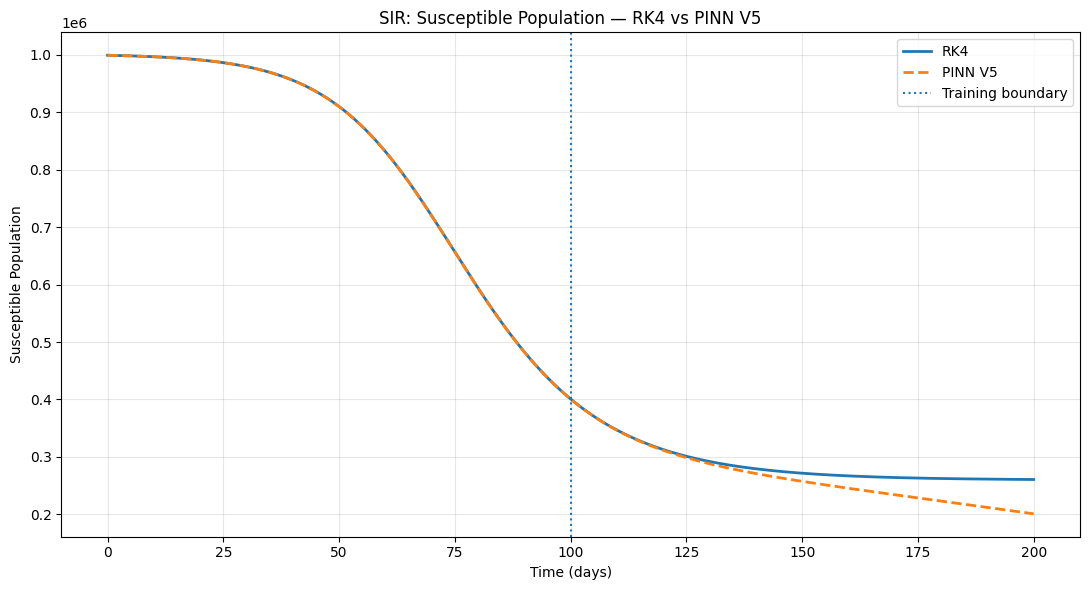

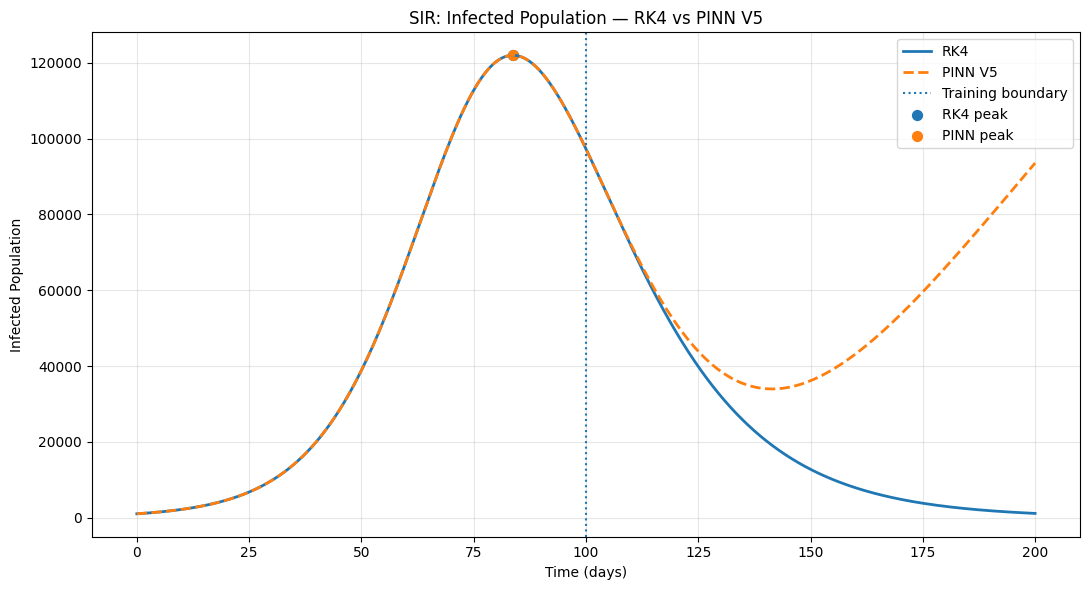

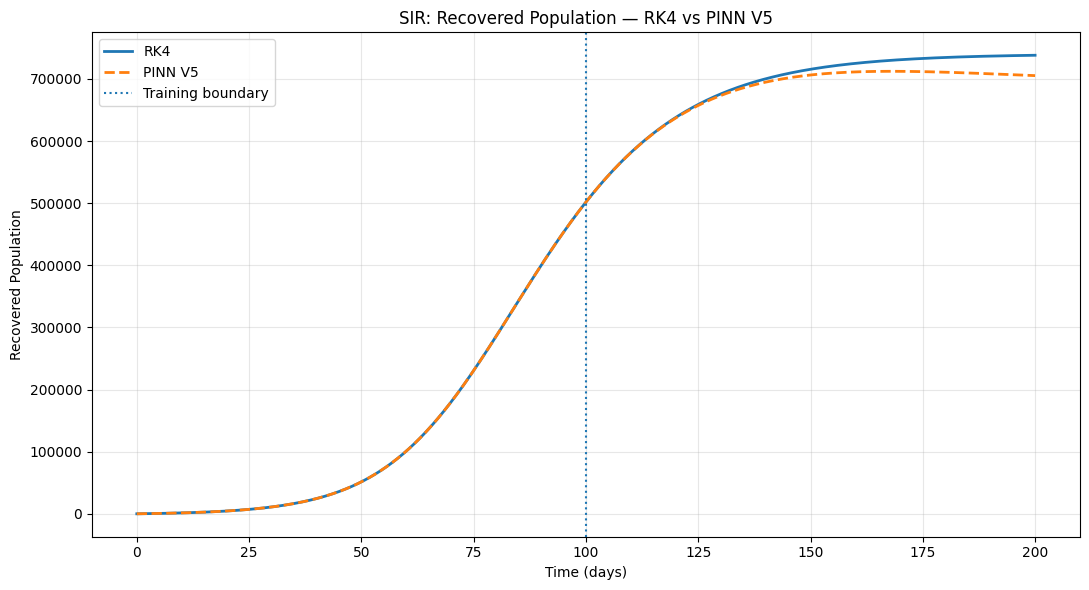

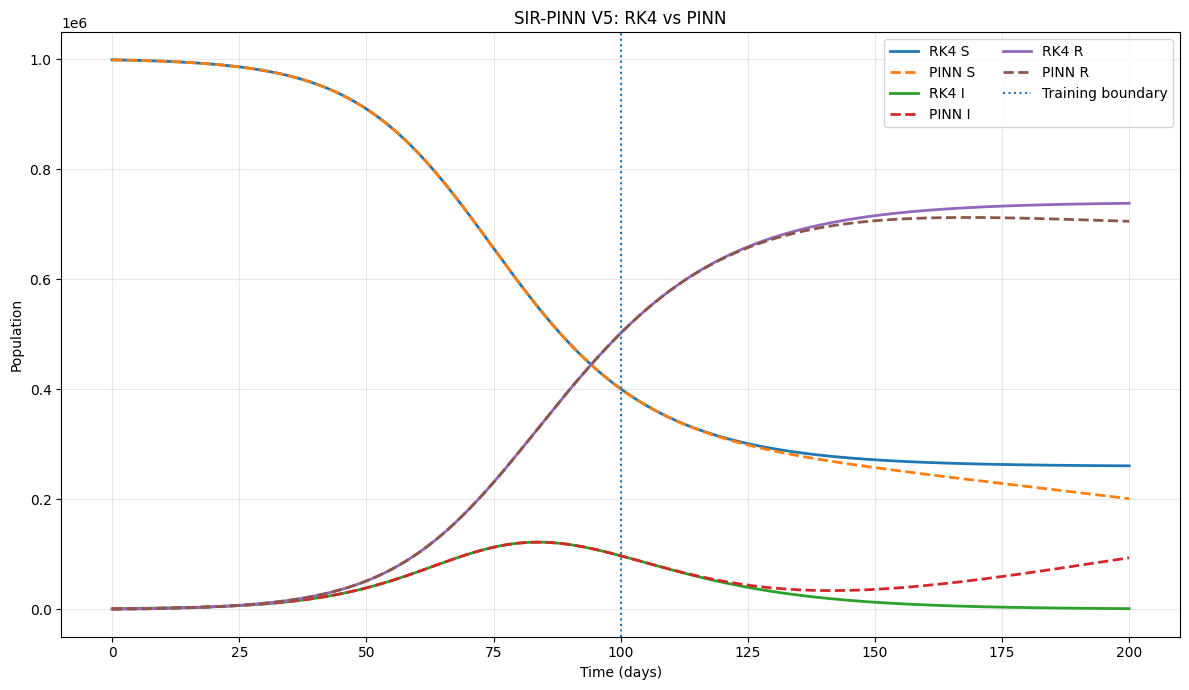

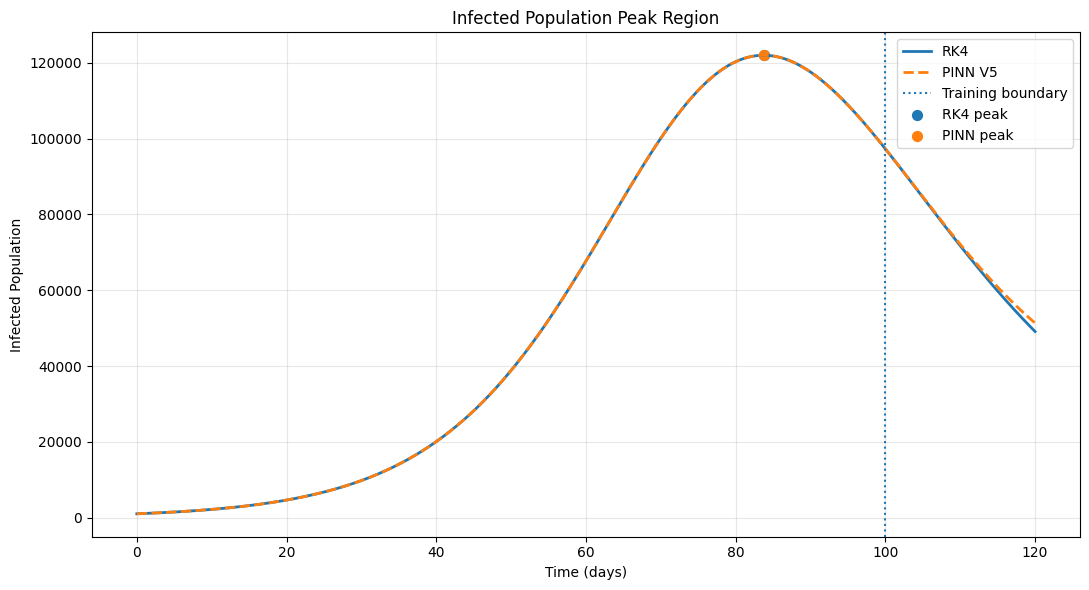

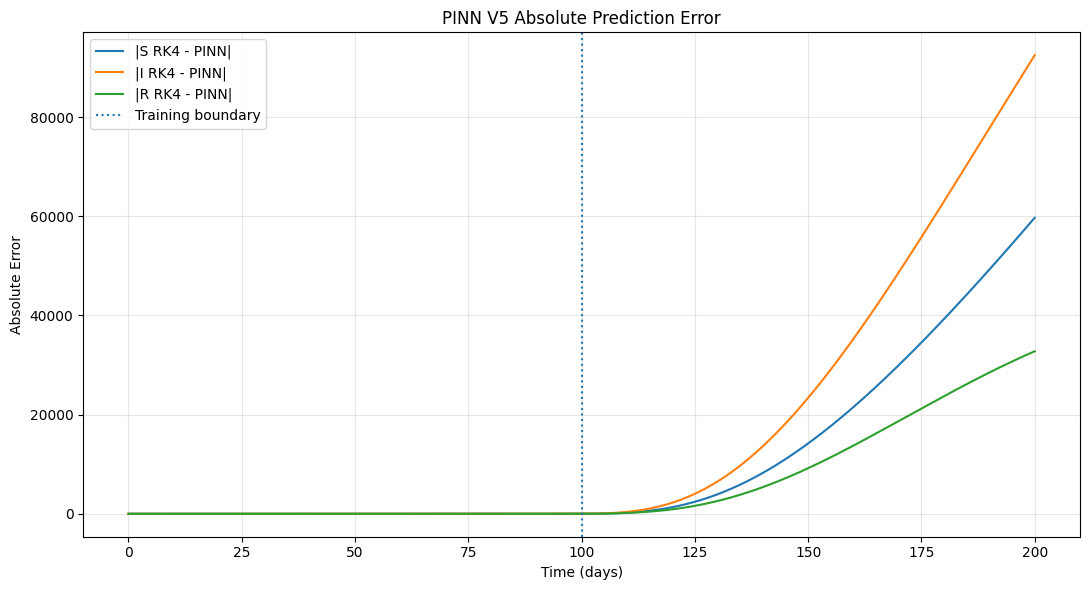

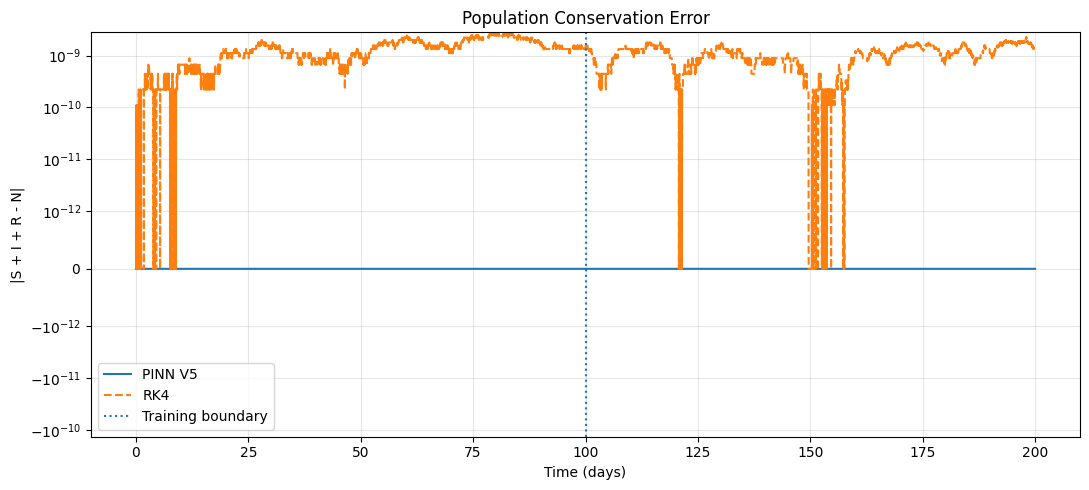

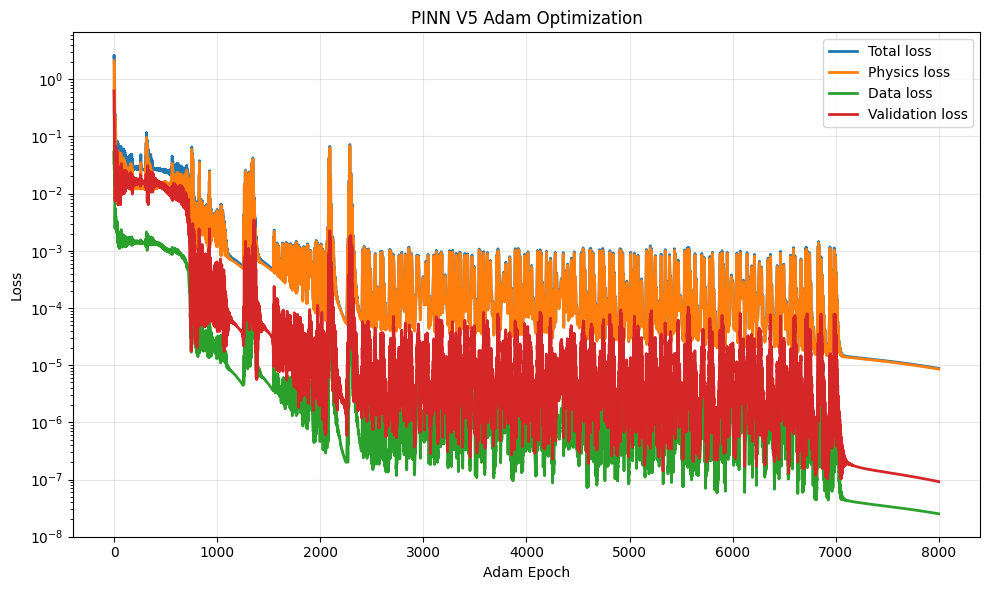

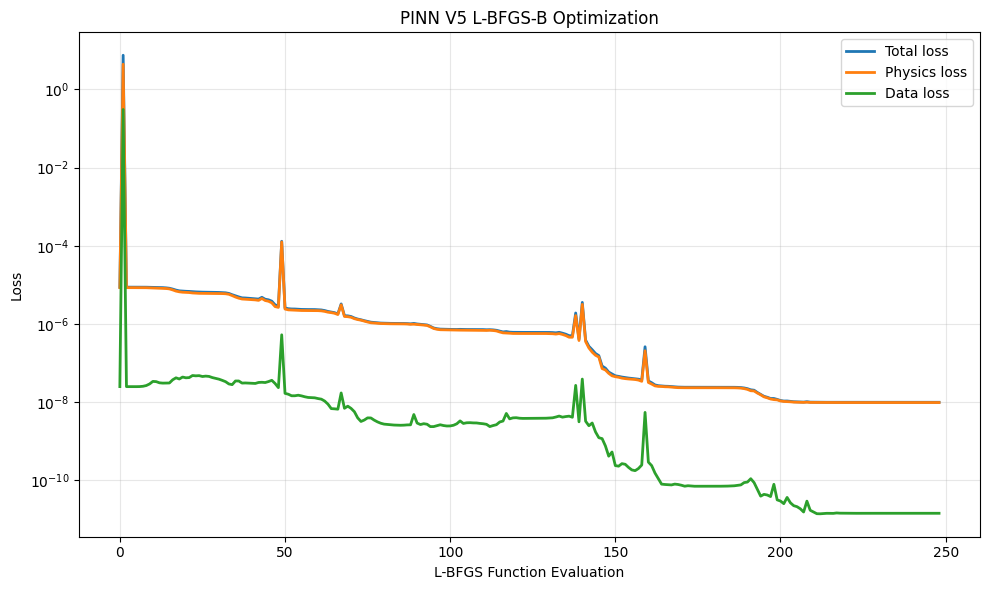

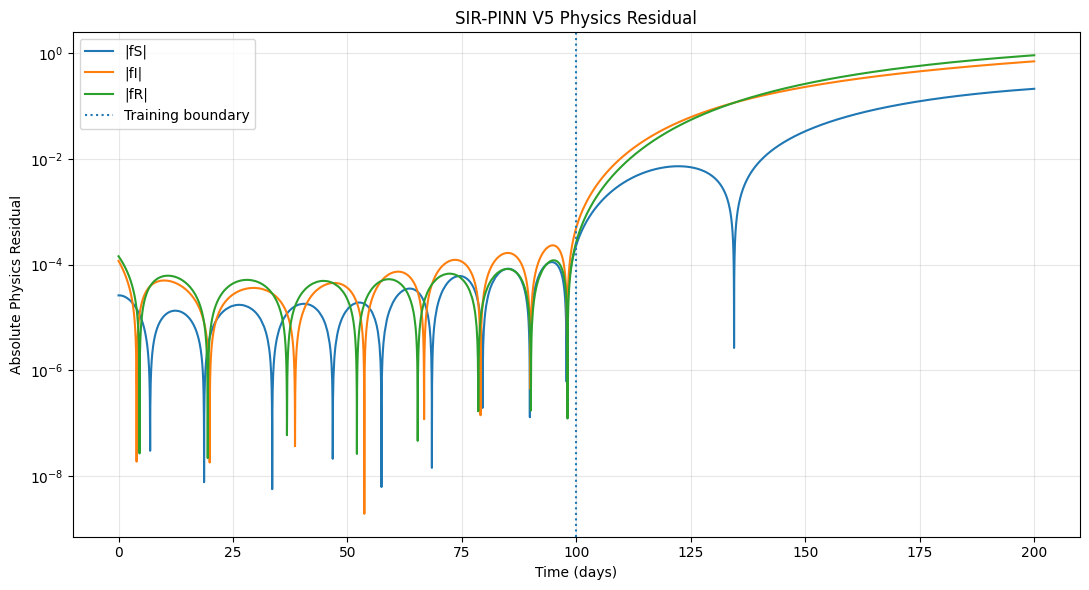



FINAL SIR-PINN V5 SUMMARY

MODEL
------------------------------------------------------------------------------------------
Architecture: 5 hidden layers × 64 neurons, tanh
Outputs: 2 neural outputs + analytical R
Precision: float64

PARAMETERS
------------------------------------------------------------------------------------------
Beta  = 0.17150948
Gamma = 0.09425424
R0    = 1.81964737

OPTIMIZATION
------------------------------------------------------------------------------------------
Adam epochs        = 8000
Adam final physics = 9.838314042208e-09
Adam/L-BFGS data loss = 1.450869983396e-11
Validation loss    = 3.283360996155e-11
L-BFGS success     = True
Total Adam time    = 803.879 sec
Total L-BFGS time  = 25.493 sec

PEAK INFECTION
------------------------------------------------------------------------------------------
RK4  = 122,004.4769 at 83.7200 days
PINN = 122,002.5547 at 83.7400 days
Peak value error = 0.00157555%
Peak timing error = 0.02000000 days

PHYSICS
-----

In [63]:
# =============================================================================
# SIR-PINN V5
# =============================================================================
#
# PROPERLY OPTIMIZED PHYSICS-INFORMED NEURAL NETWORK
# FOR THE NORMALIZED SIR MODEL
#
# -------------------------------------------------------------------------
# SIR MODEL
# -------------------------------------------------------------------------
#
#     ds/dt = - beta*s*i
#     di/dt =   beta*s*i - gamma*i
#     dr/dt =   gamma*i
#
# where
#
#     s = S/N
#     i = I/N
#     r = R/N
#
# and
#
#     s + i + r = 1
#
# -------------------------------------------------------------------------
# V5 DESIGN
# -------------------------------------------------------------------------
#
# 1. Hard initial condition
#
#       s(t) = s0 + tau * NN_s(tau)
#       i(t) = i0 + tau * NN_i(tau)
#
# 2. Hard population conservation
#
#       r(t) = 1 - s(t) - i(t)
#
# 3. Physics loss
#
#       Lphysics = weighted SIR residual
#
# 4. RK4 anchor/data loss
#
#       Ldata = MSE(PINN - RK4)
#
#    ONLY for 0-100 days.
#
# 5. Training
#
#       0-100 days
#
# 6. Extrapolation test
#
#       100-200 days
#
#    NO 100-200 day data are used during training.
#
# 7. Optimization
#
#       Adam + Reduce-on-Plateau style manual LR decay
#       followed by L-BFGS-B
#
# 8. Float64 precision
#
# 9. Balanced compartment losses
#
# 10. Extensive diagnostics
#
# =============================================================================


# =============================================================================
# 1. IMPORTS
# =============================================================================

import os
import time
import random

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# =============================================================================
# 2. GLOBAL CONFIGURATION
# =============================================================================

tf.keras.backend.set_floatx("float64")

DTYPE = tf.float64
NP_DTYPE = np.float64

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# =============================================================================
# 3. SIR PARAMETERS
# =============================================================================

BETA = 0.17150948
GAMMA = 0.09425424

S0 = 999000.0
I0 = 1000.0
R0 = 0.0

N = S0 + I0 + R0

s0 = S0 / N
i0 = I0 / N
r0 = R0 / N


print("=" * 90)
print("SIR-PINN V5")
print("=" * 90)

print(f"Population N        = {N:,.0f}")
print(f"Beta                = {BETA:.8f}")
print(f"Gamma               = {GAMMA:.8f}")
print(f"Basic reproduction R0 = {BETA / GAMMA:.8f}")

print()
print("Initial conditions")
print("-" * 90)

print(f"S0 = {S0:,.4f}")
print(f"I0 = {I0:,.4f}")
print(f"R0 = {R0:,.4f}")

print()
print("Normalized initial conditions")

print(f"s0 = {s0:.12f}")
print(f"i0 = {i0:.12f}")
print(f"r0 = {r0:.12f}")


# =============================================================================
# 4. TIME CONFIGURATION
# =============================================================================

TRAIN_START = 0.0
TRAIN_END = 100.0

EVAL_END = 200.0

TIME_SCALE = TRAIN_END


print()
print("=" * 90)
print("TIME CONFIGURATION")
print("=" * 90)

print(f"Training interval      : {TRAIN_START:.1f} - {TRAIN_END:.1f} days")
print(f"Extrapolation interval : {TRAIN_END:.1f} - {EVAL_END:.1f} days")
print(f"Time normalization     : tau = t / {TIME_SCALE:.1f}")


# =============================================================================
# 5. RK4 SOLVER
# =============================================================================

def sir_rhs(y, beta, gamma):

    s, i, r = y

    ds = -beta * s * i
    di = beta * s * i - gamma * i
    dr = gamma * i

    return np.array(
        [ds, di, dr],
        dtype=np.float64
    )


def rk4_sir(
    beta,
    gamma,
    s0,
    i0,
    r0,
    t_start=0.0,
    t_end=200.0,
    h=0.02
):

    n_steps = int(
        round(
            (t_end - t_start) / h
        )
    )

    t = np.linspace(
        t_start,
        t_end,
        n_steps + 1,
        dtype=np.float64
    )

    y = np.zeros(
        (n_steps + 1, 3),
        dtype=np.float64
    )

    y[0] = [
        s0,
        i0,
        r0
    ]

    for k in range(n_steps):

        yk = y[k]

        k1 = sir_rhs(
            yk,
            beta,
            gamma
        )

        k2 = sir_rhs(
            yk + 0.5 * h * k1,
            beta,
            gamma
        )

        k3 = sir_rhs(
            yk + 0.5 * h * k2,
            beta,
            gamma
        )

        k4 = sir_rhs(
            yk + h * k3,
            beta,
            gamma
        )

        y[k + 1] = (
            yk
            + h / 6.0
            * (
                k1
                + 2.0 * k2
                + 2.0 * k3
                + k4
            )
        )

    return t, y


# =============================================================================
# 6. COMPUTE RK4 REFERENCE
# =============================================================================

print()
print("=" * 90)
print("COMPUTING RK4 REFERENCE SOLUTION")
print("=" * 90)

rk4_start = time.time()

t_rk4, y_rk4 = rk4_sir(
    BETA,
    GAMMA,
    s0,
    i0,
    r0,
    0.0,
    EVAL_END,
    h=0.02
)

rk4_time = time.time() - rk4_start

s_rk4 = y_rk4[:, 0]
i_rk4 = y_rk4[:, 1]
r_rk4 = y_rk4[:, 2]

S_rk4 = s_rk4 * N
I_rk4 = i_rk4 * N
R_rk4 = r_rk4 * N

print(f"RK4 time = {rk4_time:.3f} seconds")
print(f"Number of RK4 points = {len(t_rk4):,}")


# =============================================================================
# 7. RK4 SANITY CHECK
# =============================================================================

rk4_peak_idx = np.argmax(I_rk4)

print()
print("=" * 90)
print("RK4 SANITY CHECK")
print("=" * 90)

print(
    f"Peak infected       = "
    f"{I_rk4[rk4_peak_idx]:,.6f}"
)

print(
    f"Peak infection time = "
    f"{t_rk4[rk4_peak_idx]:.4f} days"
)

print(
    f"Maximum conservation error = "
    f"{np.max(np.abs(y_rk4.sum(axis=1) - 1.0)):.3e}"
)


# =============================================================================
# 8. CREATE TRAINING DATA
# =============================================================================
#
# RK4 data are used ONLY from 0-100 days.
#
# 100-200 days are completely withheld from training.
#
# =============================================================================

train_time = np.linspace(
    TRAIN_START,
    TRAIN_END,
    101,
    dtype=np.float64
)

train_indices = np.searchsorted(
    t_rk4,
    train_time
)

train_s = s_rk4[train_indices]
train_i = i_rk4[train_indices]
train_r = r_rk4[train_indices]

train_y = np.column_stack([
    train_s,
    train_i,
    train_r
])


# =============================================================================
# 9. TRAIN / VALIDATION SPLIT
# =============================================================================
#
# Chronological split inside the training domain:
#
# 0-80 days       -> actual optimization
# 80-100 days     -> validation/model selection
#
# This is still entirely inside the 0-100 day training region.
#
# =============================================================================

DATA_TRAIN_END = 80.0

data_train_mask = (
    train_time <= DATA_TRAIN_END
)

data_val_mask = (
    train_time > DATA_TRAIN_END
)

t_data_train = train_time[data_train_mask]
y_data_train = train_y[data_train_mask]

t_data_val = train_time[data_val_mask]
y_data_val = train_y[data_val_mask]


print()
print("=" * 90)
print("RK4 ANCHOR DATA")
print("=" * 90)

print(
    f"Optimization data : "
    f"{t_data_train[0]:.1f} - {t_data_train[-1]:.1f} days"
)

print(
    f"Validation data   : "
    f"{t_data_val[0]:.1f} - {t_data_val[-1]:.1f} days"
)

print(
    f"Extrapolation     : "
    f"{TRAIN_END:.1f} - {EVAL_END:.1f} days"
)


# =============================================================================
# 10. ADAPTIVE COLLOCATION POINTS
# =============================================================================
#
# The epidemic dynamics are strongest around the infection peak.
#
# Therefore we allocate points to:
#
# 0-20 days       20%
# 20-60 days      50%
# 60-100 days     30%
#
# plus deterministic anchor points.
#
# =============================================================================

N_COLLOCATION = 3000

rng = np.random.default_rng(SEED)

n1 = int(0.20 * N_COLLOCATION)
n2 = int(0.50 * N_COLLOCATION)
n3 = N_COLLOCATION - n1 - n2

tc1 = rng.uniform(
    0.0,
    20.0,
    size=(n1, 1)
)

tc2 = rng.uniform(
    20.0,
    60.0,
    size=(n2, 1)
)

tc3 = rng.uniform(
    60.0,
    100.0,
    size=(n3, 1)
)


# Deterministic physics points
physics_anchor_times = np.arange(
    0.0,
    100.01,
    1.0,
    dtype=np.float64
).reshape(-1, 1)


t_collocation = np.vstack([
    tc1,
    tc2,
    tc3,
    physics_anchor_times
])


rng.shuffle(
    t_collocation
)

t_collocation = t_collocation.astype(
    np.float64
)

tau_collocation = (
    t_collocation / TIME_SCALE
)

tau_collocation_tf = tf.convert_to_tensor(
    tau_collocation,
    dtype=DTYPE
)


# =============================================================================
# 11. TENSOR TRAINING DATA
# =============================================================================

tau_data_train = (
    t_data_train.reshape(-1, 1)
    / TIME_SCALE
)

tau_data_val = (
    t_data_val.reshape(-1, 1)
    / TIME_SCALE
)

tau_data_train_tf = tf.convert_to_tensor(
    tau_data_train,
    dtype=DTYPE
)

tau_data_val_tf = tf.convert_to_tensor(
    tau_data_val,
    dtype=DTYPE
)

y_data_train_tf = tf.convert_to_tensor(
    y_data_train,
    dtype=DTYPE
)

y_data_val_tf = tf.convert_to_tensor(
    y_data_val,
    dtype=DTYPE
)


print()
print("=" * 90)
print("COLLOCATION CONFIGURATION")
print("=" * 90)

print(
    f"Physics collocation points = "
    f"{len(t_collocation):,}"
)


# =============================================================================
# 12. SIR-PINN V5 ARCHITECTURE
# =============================================================================

class SIR_PINN_V5(tf.keras.Model):

    def __init__(
        self,
        hidden_units=64,
        hidden_layers=5
    ):

        super().__init__()

        self.hidden_layers = []

        for layer_index in range(
            hidden_layers
        ):

            self.hidden_layers.append(
                tf.keras.layers.Dense(
                    hidden_units,
                    activation=tf.nn.tanh,
                    dtype=DTYPE,
                    kernel_initializer="glorot_normal",
                    bias_initializer="zeros",
                    name=f"dense_{layer_index + 1}"
                )
            )

        # Only S and I are learned directly.
        #
        # R is obtained from:
        #
        #     r = 1 - s - i
        #
        # Therefore population conservation is exact.

        self.output_layer = (
            tf.keras.layers.Dense(
                2,
                activation=None,
                dtype=DTYPE,
                kernel_initializer="glorot_normal",
                bias_initializer="zeros",
                name="sir_output"
            )
        )

        self.s0 = tf.constant(
            s0,
            dtype=DTYPE
        )

        self.i0 = tf.constant(
            i0,
            dtype=DTYPE
        )

    def call(
        self,
        tau
    ):

        tau = tf.cast(
            tau,
            DTYPE
        )

        x = tau

        for layer in self.hidden_layers:

            x = layer(x)

        raw = self.output_layer(x)

        raw_s = raw[:, 0:1]
        raw_i = raw[:, 1:2]

        # -----------------------------------------------------------------
        # HARD INITIAL CONDITIONS
        # -----------------------------------------------------------------

        s = (
            self.s0
            + tau * raw_s
        )

        i = (
            self.i0
            + tau * raw_i
        )

        # -----------------------------------------------------------------
        # HARD CONSERVATION
        # -----------------------------------------------------------------

        r = (
            tf.ones_like(s)
            - s
            - i
        )

        return tf.concat(
            [
                s,
                i,
                r
            ],
            axis=1
        )


# =============================================================================
# 13. CREATE MODEL
# =============================================================================

model = SIR_PINN_V5(
    hidden_units=64,
    hidden_layers=5
)


# Build model
dummy_input = tf.zeros(
    (1, 1),
    dtype=DTYPE
)

dummy_output = model(
    dummy_input
)


print()
print("=" * 90)
print("MODEL CHECK")
print("=" * 90)

print(
    f"Input shape  = "
    f"{dummy_input.shape}"
)

print(
    f"Output shape = "
    f"{dummy_output.shape}"
)

print(
    f"Input dtype  = "
    f"{dummy_input.dtype}"
)

print(
    f"Output dtype = "
    f"{dummy_output.dtype}"
)

print()
print("Prediction at t=0:")

print(
    model(
        tf.zeros(
            (1, 1),
            dtype=DTYPE
        )
    ).numpy()
)


# =============================================================================
# 14. SCALED SIR PARAMETERS
# =============================================================================
#
# tau = t / TIME_SCALE
#
# therefore:
#
# ds/dtau = -beta*T*s*i
#
# di/dtau = beta*T*s*i - gamma*T*i
#
# dr/dtau = gamma*T*i
#
# =============================================================================

BETA_SCALED = tf.constant(
    BETA * TIME_SCALE,
    dtype=DTYPE
)

GAMMA_SCALED = tf.constant(
    GAMMA * TIME_SCALE,
    dtype=DTYPE
)


# =============================================================================
# 15. PHYSICS RESIDUAL
# =============================================================================

@tf.function
def physics_residual(
    tau
):

    tau = tf.cast(
        tau,
        DTYPE
    )

    with tf.GradientTape(
        persistent=True
    ) as tape:

        tape.watch(tau)

        prediction = model(
            tau
        )

        s = prediction[:, 0:1]
        i = prediction[:, 1:2]
        r = prediction[:, 2:3]

    ds_dtau = tape.gradient(
        s,
        tau
    )

    di_dtau = tape.gradient(
        i,
        tau
    )

    dr_dtau = tape.gradient(
        r,
        tau
    )

    del tape

    f_s = (
        ds_dtau
        + BETA_SCALED * s * i
    )

    f_i = (
        di_dtau
        - BETA_SCALED * s * i
        + GAMMA_SCALED * i
    )

    f_r = (
        dr_dtau
        - GAMMA_SCALED * i
    )

    return (
        f_s,
        f_i,
        f_r
    )


# =============================================================================
# 16. BALANCED PHYSICS LOSS
# =============================================================================
#
# Since S, I and R behave differently, calculate each residual separately.
#
# =============================================================================

@tf.function
def physics_loss_components(
    tau
):

    f_s, f_i, f_r = physics_residual(
        tau
    )

    loss_s = tf.reduce_mean(
        tf.square(f_s)
    )

    loss_i = tf.reduce_mean(
        tf.square(f_i)
    )

    loss_r = tf.reduce_mean(
        tf.square(f_r)
    )

    return (
        loss_s,
        loss_i,
        loss_r
    )


@tf.function
def physics_loss(
    tau
):

    loss_s, loss_i, loss_r = (
        physics_loss_components(
            tau
        )
    )

    return (
        loss_s
        + loss_i
        + loss_r
    )


# =============================================================================
# 17. DATA LOSS
# =============================================================================

@tf.function
def data_loss(
    tau,
    y_true
):

    y_pred = model(
        tau
    )

    error = (
        y_pred
        - y_true
    )

    # Equal compartment weighting
    loss_s = tf.reduce_mean(
        tf.square(
            error[:, 0:1]
        )
    )

    loss_i = tf.reduce_mean(
        tf.square(
            error[:, 1:2]
        )
    )

    loss_r = tf.reduce_mean(
        tf.square(
            error[:, 2:3]
        )
    )

    return (
        loss_s
        + loss_i
        + loss_r
    )


# =============================================================================
# 18. TOTAL LOSS
# =============================================================================
#
# The data loss is intentionally included.
#
# This prevents the PINN from finding a numerically low-residual but
# poorly positioned trajectory.
#
# =============================================================================

LAMBDA_PHYSICS = 1.0
LAMBDA_DATA = 10.0


@tf.function
def total_loss(
    tau_physics,
    tau_data,
    y_data
):

    lp = physics_loss(
        tau_physics
    )

    ld = data_loss(
        tau_data,
        y_data
    )

    return (
        LAMBDA_PHYSICS * lp
        + LAMBDA_DATA * ld
    )


# =============================================================================
# 19. INITIAL LOSS
# =============================================================================

initial_physics_loss = physics_loss(
    tau_collocation_tf
)

initial_data_loss = data_loss(
    tau_data_train_tf,
    y_data_train_tf
)

initial_total_loss = total_loss(
    tau_collocation_tf,
    tau_data_train_tf,
    y_data_train_tf
)


print()
print("=" * 90)
print("INITIAL LOSSES")
print("=" * 90)

print(
    f"Physics loss = "
    f"{initial_physics_loss.numpy():.12e}"
)

print(
    f"Data loss    = "
    f"{initial_data_loss.numpy():.12e}"
)

print(
    f"Total loss   = "
    f"{initial_total_loss.numpy():.12e}"
)


# =============================================================================
# 20. ADAM TRAINING
# =============================================================================

ADAM_EPOCHS = 8000

INITIAL_LR = 1e-3
MIN_LR = 1e-6

optimizer = tf.keras.optimizers.Adam(
    learning_rate=INITIAL_LR
)


loss_history = []
physics_history = []
data_history = []
val_history = []
lr_history = []

best_val_loss = np.inf
best_weights_adam = None

start_time = time.time()


print()
print("=" * 90)
print("ADAM OPTIMIZATION")
print("=" * 90)


for epoch in range(
    1,
    ADAM_EPOCHS + 1
):

    with tf.GradientTape() as tape:

        lp = physics_loss(
            tau_collocation_tf
        )

        ld = data_loss(
            tau_data_train_tf,
            y_data_train_tf
        )

        loss = (
            LAMBDA_PHYSICS * lp
            + LAMBDA_DATA * ld
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    # Gradient clipping
    gradients, _ = tf.clip_by_global_norm(
        gradients,
        1.0
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    loss_value = float(
        loss.numpy()
    )

    physics_value = float(
        lp.numpy()
    )

    data_value = float(
        ld.numpy()
    )

    val_value = float(
        data_loss(
            tau_data_val_tf,
            y_data_val_tf
        ).numpy()
    )

    current_lr = float(
        optimizer.learning_rate.numpy()
    )

    loss_history.append(
        loss_value
    )

    physics_history.append(
        physics_value
    )

    data_history.append(
        data_value
    )

    val_history.append(
        val_value
    )

    lr_history.append(
        current_lr
    )

    # -------------------------------------------------------------
    # Save best model according to validation loss
    # -------------------------------------------------------------

    if val_value < best_val_loss:

        best_val_loss = val_value

        best_weights_adam = [
            v.numpy().copy()
            for v in model.trainable_variables
        ]

    # -------------------------------------------------------------
    # Manual learning-rate schedule
    # -------------------------------------------------------------

    if (
        epoch > 1000
        and epoch % 1000 == 0
    ):

        recent = np.array(
            val_history[-500:]
        )

        previous = np.array(
            val_history[-1000:-500]
        )

        if (
            len(previous) > 0
            and np.mean(recent)
            >=
            0.995 * np.mean(previous)
        ):

            new_lr = max(
                current_lr * 0.5,
                MIN_LR
            )

            optimizer.learning_rate.assign(
                new_lr
            )

    if (
        epoch == 1
        or epoch % 500 == 0
    ):

        print(
            f"Epoch {epoch:5d} | "
            f"Total = {loss_value:.6e} | "
            f"Physics = {physics_value:.6e} | "
            f"Data = {data_value:.6e} | "
            f"Val = {val_value:.6e} | "
            f"LR = {current_lr:.2e}"
        )


adam_time = time.time() - start_time


# =============================================================================
# 21. RESTORE BEST ADAM MODEL
# =============================================================================

if best_weights_adam is not None:

    for variable, values in zip(
        model.trainable_variables,
        best_weights_adam
    ):

        variable.assign(
            values
        )


print()
print("=" * 90)
print("ADAM COMPLETE")
print("=" * 90)

print(
    f"Training time = "
    f"{adam_time:.3f} seconds"
)

print(
    f"Best validation loss = "
    f"{best_val_loss:.12e}"
)

print(
    f"Final Adam physics loss = "
    f"{physics_loss(tau_collocation_tf).numpy():.12e}"
)

print(
    f"Final Adam data loss = "
    f"{data_loss(tau_data_train_tf, y_data_train_tf).numpy():.12e}"
)


# =============================================================================
# 22. FLATTEN MODEL WEIGHTS
# =============================================================================

def get_weights_flat():

    return np.concatenate([
        variable.numpy().reshape(-1)
        for variable in model.trainable_variables
    ]).astype(
        np.float64
    )


def set_weights_flat(
    flat_weights
):

    position = 0

    for variable in model.trainable_variables:

        size = int(
            np.prod(
                variable.shape
            )
        )

        values = flat_weights[
            position:
            position + size
        ].reshape(
            variable.shape
        )

        variable.assign(
            values
        )

        position += size


# =============================================================================
# 23. L-BFGS LOSS AND GRADIENT
# =============================================================================

lbfgs_loss_history = []

lbfgs_physics_history = []
lbfgs_data_history = []


def loss_and_gradient(
    flat_weights
):

    set_weights_flat(
        flat_weights
    )

    with tf.GradientTape() as tape:

        lp = physics_loss(
            tau_collocation_tf
        )

        ld = data_loss(
            tau_data_train_tf,
            y_data_train_tf
        )

        loss = (
            LAMBDA_PHYSICS * lp
            + LAMBDA_DATA * ld
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    flat_gradients = []

    for gradient in gradients:

        if gradient is None:

            raise RuntimeError(
                "Gradient is None."
            )

        flat_gradients.append(
            gradient.numpy().reshape(-1)
        )

    flat_gradient = np.concatenate(
        flat_gradients
    ).astype(
        np.float64
    )

    loss_value = float(
        loss.numpy()
    )

    physics_value = float(
        lp.numpy()
    )

    data_value = float(
        ld.numpy()
    )

    lbfgs_loss_history.append(
        loss_value
    )

    lbfgs_physics_history.append(
        physics_value
    )

    lbfgs_data_history.append(
        data_value
    )

    return (
        loss_value,
        flat_gradient
    )


# =============================================================================
# 24. L-BFGS-B OPTIMIZATION
# =============================================================================

print()
print("=" * 90)
print("L-BFGS-B OPTIMIZATION")
print("=" * 90)


initial_weights = get_weights_flat()

lbfgs_start = time.time()


def lbfgs_callback(
    weights
):

    n = len(
        lbfgs_loss_history
    )

    if (
        n == 1
        or n % 25 == 0
    ):

        print(
            f"L-BFGS evaluation {n:5d} | "
            f"Total = "
            f"{lbfgs_loss_history[-1]:.12e} | "
            f"Physics = "
            f"{lbfgs_physics_history[-1]:.12e} | "
            f"Data = "
            f"{lbfgs_data_history[-1]:.12e}"
        )


result = minimize(
    fun=loss_and_gradient,
    x0=initial_weights,
    jac=True,
    method="L-BFGS-B",
    callback=lbfgs_callback,
    options={
        "maxiter": 2000,
        "maxfun": 4000,
        "maxls": 50,
        "ftol": 1e-14,
        "gtol": 1e-10,
        "maxcor": 30
    }
)


set_weights_flat(
    result.x
)


lbfgs_time = (
    time.time()
    - lbfgs_start
)


print()
print("=" * 90)
print("L-BFGS-B RESULT")
print("=" * 90)

print(
    f"Success       = "
    f"{result.success}"
)

print(
    f"Status        = "
    f"{result.status}"
)

print(
    f"Message       = "
    f"{result.message}"
)

print(
    f"Iterations    = "
    f"{result.nit}"
)

print(
    f"Function eval = "
    f"{result.nfev}"
)

print(
    f"Time          = "
    f"{lbfgs_time:.3f} seconds"
)

print(
    f"Final loss    = "
    f"{result.fun:.12e}"
)


# =============================================================================
# 25. FINAL LOSSES
# =============================================================================

final_physics_loss = physics_loss(
    tau_collocation_tf
)

final_train_data_loss = data_loss(
    tau_data_train_tf,
    y_data_train_tf
)

final_validation_loss = data_loss(
    tau_data_val_tf,
    y_data_val_tf
)


print()
print("=" * 90)
print("FINAL LOSSES")
print("=" * 90)

print(
    f"Physics loss      = "
    f"{final_physics_loss.numpy():.12e}"
)

print(
    f"Training data loss = "
    f"{final_train_data_loss.numpy():.12e}"
)

print(
    f"Validation loss   = "
    f"{final_validation_loss.numpy():.12e}"
)


# =============================================================================
# 26. PREDICTION FUNCTION
# =============================================================================

def predict_normalized(
    t
):

    t = np.asarray(
        t,
        dtype=np.float64
    ).reshape(-1, 1)

    tau = (
        t / TIME_SCALE
    )

    tau_tf = tf.convert_to_tensor(
        tau,
        dtype=DTYPE
    )

    prediction = model(
        tau_tf
    ).numpy()

    return prediction


def predict_population(
    t
):

    prediction = predict_normalized(
        t
    )

    S = prediction[:, 0] * N
    I = prediction[:, 1] * N
    R = prediction[:, 2] * N

    return (
        S,
        I,
        R
    )


# =============================================================================
# 27. EVALUATION
# =============================================================================

t_eval = t_rk4.copy()

pinn_normalized = predict_normalized(
    t_eval
)

s_pinn = pinn_normalized[:, 0]
i_pinn = pinn_normalized[:, 1]
r_pinn = pinn_normalized[:, 2]

S_pinn = s_pinn * N
I_pinn = i_pinn * N
R_pinn = r_pinn * N


# =============================================================================
# 28. METRIC FUNCTION
# =============================================================================

def calculate_metrics(
    true,
    predicted
):

    mae = mean_absolute_error(
        true,
        predicted
    )

    mse = mean_squared_error(
        true,
        predicted
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        true,
        predicted
    )

    relative_l2 = (
        np.linalg.norm(
            predicted - true
        )
        /
        np.linalg.norm(
            true
        )
    )

    max_error = np.max(
        np.abs(
            predicted - true
        )
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Relative_L2": relative_l2,
        "Max_Error": max_error
    }


# =============================================================================
# 29. REGION METRICS
# =============================================================================

train_mask = (
    t_eval <= 100.0
)

extra_mask = (
    t_eval > 100.0
)

overall_mask = np.ones_like(
    t_eval,
    dtype=bool
)


def calculate_region_results(
    mask
):

    compartments = [
        ("S", S_rk4, S_pinn),
        ("I", I_rk4, I_pinn),
        ("R", R_rk4, R_pinn)
    ]

    results_dict = {}

    for name, true, pred in compartments:

        results_dict[name] = (
            calculate_metrics(
                true[mask],
                pred[mask]
            )
        )

    return results_dict


train_results = calculate_region_results(
    train_mask
)

extra_results = calculate_region_results(
    extra_mask
)

overall_results = calculate_region_results(
    overall_mask
)


# =============================================================================
# 30. PRINT REGION METRICS
# =============================================================================

def print_region_metrics(
    region_name,
    results_dict
):

    print()
    print("=" * 90)
    print(region_name)
    print("=" * 90)

    for compartment in [
        "S",
        "I",
        "R"
    ]:

        m = results_dict[
            compartment
        ]

        print()
        print(
            f"{compartment}"
        )

        print(
            f"MAE        = "
            f"{m['MAE']:,.8f}"
        )

        print(
            f"MSE        = "
            f"{m['MSE']:,.8f}"
        )

        print(
            f"RMSE       = "
            f"{m['RMSE']:,.8f}"
        )

        print(
            f"R²         = "
            f"{m['R2']:.12f}"
        )

        print(
            f"Relative L2 = "
            f"{m['Relative_L2']:.12e}"
        )

        print(
            f"Max Error  = "
            f"{m['Max_Error']:,.8f}"
        )


print_region_metrics(
    "PINN V5 — TRAINING REGION: 0-100 DAYS",
    train_results
)

print_region_metrics(
    "PINN V5 — EXTRAPOLATION REGION: 100-200 DAYS",
    extra_results
)

print_region_metrics(
    "PINN V5 — OVERALL REGION: 0-200 DAYS",
    overall_results
)


# =============================================================================
# 31. NORMALIZED METRICS
# =============================================================================

print()
print("=" * 90)
print("NORMALIZED METRICS — 0-200 DAYS")
print("=" * 90)

for name, true, pred in [
    ("S", s_rk4, s_pinn),
    ("I", i_rk4, i_pinn),
    ("R", r_rk4, r_pinn)
]:

    m = calculate_metrics(
        true,
        pred
    )

    print()
    print(name)

    print(
        f"MAE        = "
        f"{m['MAE']:.12e}"
    )

    print(
        f"RMSE       = "
        f"{m['RMSE']:.12e}"
    )

    print(
        f"R²         = "
        f"{m['R2']:.12f}"
    )

    print(
        f"Relative L2 = "
        f"{m['Relative_L2']:.12e}"
    )


# =============================================================================
# 32. PEAK INFECTED COMPARISON
# =============================================================================

rk4_peak_idx = np.argmax(
    I_rk4
)

pinn_peak_idx = np.argmax(
    I_pinn
)

rk4_peak_I = I_rk4[
    rk4_peak_idx
]

pinn_peak_I = I_pinn[
    pinn_peak_idx
]

rk4_peak_time = t_eval[
    rk4_peak_idx
]

pinn_peak_time = t_eval[
    pinn_peak_idx
]

peak_value_error = (
    abs(
        pinn_peak_I
        - rk4_peak_I
    )
    /
    rk4_peak_I
    * 100.0
)

peak_time_error = abs(
    pinn_peak_time
    - rk4_peak_time
)


print()
print("=" * 90)
print("PEAK INFECTED COMPARISON")
print("=" * 90)

print(
    f"RK4  peak I = "
    f"{rk4_peak_I:,.6f}"
)

print(
    f"PINN peak I = "
    f"{pinn_peak_I:,.6f}"
)

print()

print(
    f"RK4  peak time = "
    f"{rk4_peak_time:.4f} days"
)

print(
    f"PINN peak time = "
    f"{pinn_peak_time:.4f} days"
)

print()

print(
    f"Peak value error = "
    f"{peak_value_error:.8f}%"
)

print(
    f"Peak timing error = "
    f"{peak_time_error:.8f} days"
)


# =============================================================================
# 33. INITIAL CONDITION CHECK
# =============================================================================

tau_zero = tf.constant(
    [[0.0]],
    dtype=DTYPE
)

prediction_zero = model(
    tau_zero
).numpy()[0]


print()
print("=" * 90)
print("INITIAL CONDITION CHECK")
print("=" * 90)

print(
    f"s(0) exact = "
    f"{s0:.15f}"
)

print(
    f"s(0) PINN  = "
    f"{prediction_zero[0]:.15f}"
)

print()

print(
    f"i(0) exact = "
    f"{i0:.15f}"
)

print(
    f"i(0) PINN  = "
    f"{prediction_zero[1]:.15f}"
)

print()

print(
    f"r(0) exact = "
    f"{r0:.15f}"
)

print(
    f"r(0) PINN  = "
    f"{prediction_zero[2]:.15f}"
)


# =============================================================================
# 34. INITIAL DERIVATIVE CHECK
# =============================================================================

with tf.GradientTape(
    persistent=True
) as tape:

    tape.watch(
        tau_zero
    )

    pred_zero = model(
        tau_zero
    )

    s_zero = pred_zero[:, 0:1]
    i_zero = pred_zero[:, 1:2]
    r_zero = pred_zero[:, 2:3]


ds_dtau_zero = tape.gradient(
    s_zero,
    tau_zero
)

di_dtau_zero = tape.gradient(
    i_zero,
    tau_zero
)

dr_dtau_zero = tape.gradient(
    r_zero,
    tau_zero
)

del tape


ds_dt_zero = (
    ds_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)

di_dt_zero = (
    di_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)

dr_dt_zero = (
    dr_dtau_zero.numpy()[0, 0]
    / TIME_SCALE
)


exact_ds = (
    -BETA
    * s0
    * i0
)

exact_di = (
    BETA
    * s0
    * i0
    - GAMMA
    * i0
)

exact_dr = (
    GAMMA
    * i0
)


print()
print("=" * 90)
print("INITIAL DERIVATIVE CHECK")
print("=" * 90)

print(
    f"Exact dS/dt = "
    f"{exact_ds:.12e}"
)

print(
    f"PINN  dS/dt = "
    f"{ds_dt_zero:.12e}"
)

print()

print(
    f"Exact dI/dt = "
    f"{exact_di:.12e}"
)

print(
    f"PINN  dI/dt = "
    f"{di_dt_zero:.12e}"
)

print()

print(
    f"Exact dR/dt = "
    f"{exact_dr:.12e}"
)

print(
    f"PINN  dR/dt = "
    f"{dr_dt_zero:.12e}"
)

print()

print(
    f"Exact dI/dt = "
    f"{exact_di * N:.8f} people/day"
)

print(
    f"PINN  dI/dt = "
    f"{di_dt_zero * N:.8f} people/day"
)


# =============================================================================
# 35. POPULATION CONSERVATION
# =============================================================================

pinn_sum = (
    s_pinn
    + i_pinn
    + r_pinn
)

pinn_conservation_error = (
    np.abs(
        pinn_sum - 1.0
    )
    * N
)

rk4_sum = (
    s_rk4
    + i_rk4
    + r_rk4
)

rk4_conservation_error = (
    np.abs(
        rk4_sum - 1.0
    )
    * N
)


print()
print("=" * 90)
print("POPULATION CONSERVATION")
print("=" * 90)

print(
    f"Maximum RK4 error  = "
    f"{np.max(rk4_conservation_error):.12e}"
)

print(
    f"Maximum PINN error = "
    f"{np.max(pinn_conservation_error):.12e}"
)

print(
    f"Mean PINN error    = "
    f"{np.mean(pinn_conservation_error):.12e}"
)


# =============================================================================
# 36. COMPARTMENT RANGE CHECK
# =============================================================================

print()
print("=" * 90)
print("COMPARTMENT RANGE CHECK")
print("=" * 90)

for name, values in [
    ("S", S_pinn),
    ("I", I_pinn),
    ("R", R_pinn)
]:

    print()
    print(
        f"{name} minimum = "
        f"{np.min(values):,.8f}"
    )

    print(
        f"{name} maximum = "
        f"{np.max(values):,.8f}"
    )


negative_S = np.sum(
    S_pinn < 0
)

negative_I = np.sum(
    I_pinn < 0
)

negative_R = np.sum(
    R_pinn < 0
)

print()
print(
    f"Negative S points = {negative_S}"
)

print(
    f"Negative I points = {negative_I}"
)

print(
    f"Negative R points = {negative_R}"
)


# =============================================================================
# 37. PHYSICS RESIDUAL — 0-100 DAYS
# =============================================================================

tau_physics_eval = (
    t_eval[train_mask]
    / TIME_SCALE
).reshape(-1, 1)

tau_physics_eval_tf = tf.convert_to_tensor(
    tau_physics_eval,
    dtype=DTYPE
)

f_s_train, f_i_train, f_r_train = (
    physics_residual(
        tau_physics_eval_tf
    )
)

f_s_train_np = (
    f_s_train.numpy().flatten()
)

f_i_train_np = (
    f_i_train.numpy().flatten()
)

f_r_train_np = (
    f_r_train.numpy().flatten()
)


# =============================================================================
# 38. PHYSICS RESIDUAL — 100-200 DAYS
# =============================================================================
#
# This is diagnostic only.
#
# It is NOT used for training.
#
# =============================================================================

tau_physics_extra = (
    t_eval[extra_mask]
    / TIME_SCALE
).reshape(-1, 1)

tau_physics_extra_tf = tf.convert_to_tensor(
    tau_physics_extra,
    dtype=DTYPE
)

f_s_extra, f_i_extra, f_r_extra = (
    physics_residual(
        tau_physics_extra_tf
    )
)

f_s_extra_np = (
    f_s_extra.numpy().flatten()
)

f_i_extra_np = (
    f_i_extra.numpy().flatten()
)

f_r_extra_np = (
    f_r_extra.numpy().flatten()
)


def residual_rmse(
    a,
    b,
    c
):

    return np.sqrt(
        np.mean(
            a**2
            + b**2
            + c**2
        )
    )


train_physics_rmse = residual_rmse(
    f_s_train_np,
    f_i_train_np,
    f_r_train_np
)

extra_physics_rmse = residual_rmse(
    f_s_extra_np,
    f_i_extra_np,
    f_r_extra_np
)


print()
print("=" * 90)
print("PHYSICS RESIDUAL DIAGNOSTICS")
print("=" * 90)

print(
    f"0-100 day physics RMSE   = "
    f"{train_physics_rmse:.12e}"
)

print(
    f"100-200 day physics RMSE = "
    f"{extra_physics_rmse:.12e}"
)


# =============================================================================
# 39. SAVE MAIN RESULTS
# =============================================================================

results_df = pd.DataFrame({

    "Time_days": t_eval,

    "RK4_S": S_rk4,
    "PINN_S": S_pinn,

    "RK4_I": I_rk4,
    "PINN_I": I_pinn,

    "RK4_R": R_rk4,
    "PINN_R": R_pinn,

    "S_abs_error": np.abs(
        S_rk4 - S_pinn
    ),

    "I_abs_error": np.abs(
        I_rk4 - I_pinn
    ),

    "R_abs_error": np.abs(
        R_rk4 - R_pinn
    ),

    "PINN_conservation_error": (
        pinn_conservation_error
    )
})


results_df.to_csv(
    "sir_pinn_v5_results.csv",
    index=False
)


# =============================================================================
# 40. SAVE METRICS
# =============================================================================

metric_rows = []


for region_name, region_results in [
    (
        "Training_0_100",
        train_results
    ),
    (
        "Extrapolation_100_200",
        extra_results
    ),
    (
        "Overall_0_200",
        overall_results
    )
]:

    for compartment in [
        "S",
        "I",
        "R"
    ]:

        m = region_results[
            compartment
        ]

        metric_rows.append({

            "Region": region_name,

            "Compartment": compartment,

            "MAE": m["MAE"],

            "MSE": m["MSE"],

            "RMSE": m["RMSE"],

            "R2": m["R2"],

            "Relative_L2": m["Relative_L2"],

            "Max_Error": m["Max_Error"]
        })


metrics_df = pd.DataFrame(
    metric_rows
)

metrics_df.to_csv(
    "sir_pinn_v5_metrics.csv",
    index=False
)


# =============================================================================
# 41. SAVE OPTIMIZATION HISTORY
# =============================================================================

history_df = pd.DataFrame({

    "Adam_Epoch": np.arange(
        1,
        len(loss_history) + 1
    ),

    "Total_Loss": loss_history,

    "Physics_Loss": physics_history,

    "Data_Loss": data_history,

    "Validation_Loss": val_history,

    "Learning_Rate": lr_history
})

history_df.to_csv(
    "sir_pinn_v5_training_history.csv",
    index=False
)


if len(lbfgs_loss_history) > 0:

    lbfgs_df = pd.DataFrame({

        "Evaluation": np.arange(
            1,
            len(lbfgs_loss_history) + 1
        ),

        "Total_Loss": lbfgs_loss_history,

        "Physics_Loss": lbfgs_physics_history,

        "Data_Loss": lbfgs_data_history
    })

    lbfgs_df.to_csv(
        "sir_pinn_v5_lbfgs_history.csv",
        index=False
    )


# =============================================================================
# 42. SAVE MODEL
# =============================================================================

model.save_weights(
    "sir_pinn_v5.weights.h5"
)


# =============================================================================
# 43. PLOT — S COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    S_rk4,
    label="RK4",
    linewidth=2
)

plt.plot(
    t_eval,
    S_pinn,
    "--",
    label="PINN V5",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Susceptible Population"
)

plt.title(
    "SIR: Susceptible Population — RK4 vs PINN V5"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_S.png",
    dpi=300
)

plt.show()


# =============================================================================
# 44. PLOT — I COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    I_rk4,
    label="RK4",
    linewidth=2
)

plt.plot(
    t_eval,
    I_pinn,
    "--",
    label="PINN V5",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.scatter(
    rk4_peak_time,
    rk4_peak_I,
    s=50,
    label="RK4 peak"
)

plt.scatter(
    pinn_peak_time,
    pinn_peak_I,
    s=50,
    label="PINN peak"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Infected Population"
)

plt.title(
    "SIR: Infected Population — RK4 vs PINN V5"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_I.png",
    dpi=300
)

plt.show()


# =============================================================================
# 45. PLOT — R COMPARTMENT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    R_rk4,
    label="RK4",
    linewidth=2
)

plt.plot(
    t_eval,
    R_pinn,
    "--",
    label="PINN V5",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Recovered Population"
)

plt.title(
    "SIR: Recovered Population — RK4 vs PINN V5"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_R.png",
    dpi=300
)

plt.show()


# =============================================================================
# 46. ALL COMPARTMENTS
# =============================================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    t_eval,
    S_rk4,
    label="RK4 S",
    linewidth=2
)

plt.plot(
    t_eval,
    S_pinn,
    "--",
    label="PINN S",
    linewidth=2
)

plt.plot(
    t_eval,
    I_rk4,
    label="RK4 I",
    linewidth=2
)

plt.plot(
    t_eval,
    I_pinn,
    "--",
    label="PINN I",
    linewidth=2
)

plt.plot(
    t_eval,
    R_rk4,
    label="RK4 R",
    linewidth=2
)

plt.plot(
    t_eval,
    R_pinn,
    "--",
    label="PINN R",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Population"
)

plt.title(
    "SIR-PINN V5: RK4 vs PINN"
)

plt.legend(
    ncol=2
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_all_compartments.png",
    dpi=300
)

plt.show()


# =============================================================================
# 47. INFECTED PEAK ZOOM
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

zoom_mask = (
    t_eval <= 120
)

plt.plot(
    t_eval[zoom_mask],
    I_rk4[zoom_mask],
    label="RK4",
    linewidth=2
)

plt.plot(
    t_eval[zoom_mask],
    I_pinn[zoom_mask],
    "--",
    label="PINN V5",
    linewidth=2
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.scatter(
    rk4_peak_time,
    rk4_peak_I,
    s=50,
    label="RK4 peak"
)

plt.scatter(
    pinn_peak_time,
    pinn_peak_I,
    s=50,
    label="PINN peak"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Infected Population"
)

plt.title(
    "Infected Population Peak Region"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_infected_zoom.png",
    dpi=300
)

plt.show()


# =============================================================================
# 48. ABSOLUTE ERROR
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_eval,
    np.abs(
        S_rk4 - S_pinn
    ),
    label="|S RK4 - PINN|"
)

plt.plot(
    t_eval,
    np.abs(
        I_rk4 - I_pinn
    ),
    label="|I RK4 - PINN|"
)

plt.plot(
    t_eval,
    np.abs(
        R_rk4 - R_pinn
    ),
    label="|R RK4 - PINN|"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Absolute Error"
)

plt.title(
    "PINN V5 Absolute Prediction Error"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_absolute_errors.png",
    dpi=300
)

plt.show()


# =============================================================================
# 49. CONSERVATION ERROR
# =============================================================================

plt.figure(
    figsize=(11, 5)
)

plt.plot(
    t_eval,
    pinn_conservation_error,
    label="PINN V5"
)

plt.plot(
    t_eval,
    rk4_conservation_error,
    "--",
    label="RK4"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "|S + I + R - N|"
)

plt.title(
    "Population Conservation Error"
)

plt.yscale(
    "symlog",
    linthresh=1e-12
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_conservation.png",
    dpi=300
)

plt.show()


# =============================================================================
# 50. ADAM LOSS
# =============================================================================

plt.figure(
    figsize=(10, 6)
)

plt.semilogy(
    loss_history,
    label="Total loss",
    linewidth=2
)

plt.semilogy(
    physics_history,
    label="Physics loss",
    linewidth=2
)

plt.semilogy(
    data_history,
    label="Data loss",
    linewidth=2
)

plt.semilogy(
    val_history,
    label="Validation loss",
    linewidth=2
)

plt.xlabel(
    "Adam Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "PINN V5 Adam Optimization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_adam_loss.png",
    dpi=300
)

plt.show()


# =============================================================================
# 51. L-BFGS LOSS
# =============================================================================

if len(lbfgs_loss_history) > 0:

    plt.figure(
        figsize=(10, 6)
    )

    plt.semilogy(
        lbfgs_loss_history,
        label="Total loss",
        linewidth=2
    )

    plt.semilogy(
        lbfgs_physics_history,
        label="Physics loss",
        linewidth=2
    )

    plt.semilogy(
        lbfgs_data_history,
        label="Data loss",
        linewidth=2
    )

    plt.xlabel(
        "L-BFGS Function Evaluation"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        "PINN V5 L-BFGS-B Optimization"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        "sir_pinn_v5_lbfgs_loss.png",
        dpi=300
    )

    plt.show()


# =============================================================================
# 52. PHYSICS RESIDUAL PLOT
# =============================================================================

plt.figure(
    figsize=(11, 6)
)

plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_s_train_np,
            f_s_extra_np
        ])
    ) + 1e-30,
    label="|fS|"
)

plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_i_train_np,
            f_i_extra_np
        ])
    ) + 1e-30,
    label="|fI|"
)

plt.semilogy(
    t_eval,
    np.abs(
        np.concatenate([
            f_r_train_np,
            f_r_extra_np
        ])
    ) + 1e-30,
    label="|fR|"
)

plt.axvline(
    TRAIN_END,
    linestyle=":",
    linewidth=1.5,
    label="Training boundary"
)

plt.xlabel(
    "Time (days)"
)

plt.ylabel(
    "Absolute Physics Residual"
)

plt.title(
    "SIR-PINN V5 Physics Residual"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "sir_pinn_v5_physics_residual.png",
    dpi=300
)

plt.show()


# =============================================================================
# 53. FINAL SUMMARY
# =============================================================================

print()
print()
print("=" * 90)
print("FINAL SIR-PINN V5 SUMMARY")
print("=" * 90)

print()
print("MODEL")
print("-" * 90)

print(
    "Architecture: "
    "5 hidden layers × 64 neurons, tanh"
)

print(
    "Outputs: "
    "2 neural outputs + analytical R"
)

print(
    "Precision: float64"
)

print()
print("PARAMETERS")
print("-" * 90)

print(
    f"Beta  = {BETA:.8f}"
)

print(
    f"Gamma = {GAMMA:.8f}"
)

print(
    f"R0    = {BETA / GAMMA:.8f}"
)

print()
print("OPTIMIZATION")
print("-" * 90)

print(
    f"Adam epochs        = {ADAM_EPOCHS}"
)

print(
    f"Adam final physics = "
    f"{final_physics_loss.numpy():.12e}"
)

print(
    f"Adam/L-BFGS data loss = "
    f"{final_train_data_loss.numpy():.12e}"
)

print(
    f"Validation loss    = "
    f"{final_validation_loss.numpy():.12e}"
)

print(
    f"L-BFGS success     = "
    f"{result.success}"
)

print(
    f"Total Adam time    = "
    f"{adam_time:.3f} sec"
)

print(
    f"Total L-BFGS time  = "
    f"{lbfgs_time:.3f} sec"
)

print()
print("PEAK INFECTION")
print("-" * 90)

print(
    f"RK4  = "
    f"{rk4_peak_I:,.4f} "
    f"at {rk4_peak_time:.4f} days"
)

print(
    f"PINN = "
    f"{pinn_peak_I:,.4f} "
    f"at {pinn_peak_time:.4f} days"
)

print(
    f"Peak value error = "
    f"{peak_value_error:.8f}%"
)

print(
    f"Peak timing error = "
    f"{peak_time_error:.8f} days"
)

print()
print("PHYSICS")
print("-" * 90)

print(
    f"0-100 residual RMSE = "
    f"{train_physics_rmse:.12e}"
)

print(
    f"100-200 residual RMSE = "
    f"{extra_physics_rmse:.12e}"
)

print()
print("CONSERVATION")
print("-" * 90)

print(
    f"Maximum PINN conservation error = "
    f"{np.max(pinn_conservation_error):.12e}"
)

print()
print("FILES SAVED")
print("-" * 90)

files_to_save = [

    "sir_pinn_v5_results.csv",

    "sir_pinn_v5_metrics.csv",

    "sir_pinn_v5_training_history.csv",

    "sir_pinn_v5_lbfgs_history.csv",

    "sir_pinn_v5.weights.h5",

    "sir_pinn_v5_S.png",

    "sir_pinn_v5_I.png",

    "sir_pinn_v5_R.png",

    "sir_pinn_v5_all_compartments.png",

    "sir_pinn_v5_infected_zoom.png",

    "sir_pinn_v5_absolute_errors.png",

    "sir_pinn_v5_conservation.png",

    "sir_pinn_v5_adam_loss.png",

    "sir_pinn_v5_lbfgs_loss.png",

    "sir_pinn_v5_physics_residual.png"
]

for filename in files_to_save:

    print(filename)


print()
print("=" * 90)
print("SIR-PINN V5 COMPLETE")
print("=" * 90)


***
### References
[^1]: Pant B, Levine ME, Nande A, Garcia RG, Dewey G, Link NB, Santillana M. Resolving parameter uncertainty in SIR models through population-level serological surveillance: A synthetic study. *Infect Dis Model*. 2026;11(4):1491-1503. doi:10.1016/j.idm.2026.05.004
<br>[^2] Tuncer N, Le TT. Structural and practical identifiability analysis of outbreak models. Math Biosci. 2018 May;299:1-18. doi: 10.1016/j.mbs.2018.02.004. Epub 2018 Mar 29. PMID: 29477671.